In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gurobipy import *
import gurobipy as gp
from gurobipy import GRB
sns.set(style ="whitegrid", font_scale=1.5)
from matplotlib.ticker import MultipleLocator
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
custom_colors = ["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)
color_palette = np.array(["#c45161", "#e094a0", "#f2b6c0", "#f2dde1", "#cbc7d8", "#8db7d2", "#5e62a9", "#434279"])
color = ['#93003a', '#00429d', '#93c4d2', '#6ebf7c']
matplotlib.rcParams.update({'legend.fontsize': 14, 'legend.handlelength': 2})
from tqdm import tqdm
import sys
import os
import pickle
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import importlib
import re
from geopy.distance import geodesic

### Prepare input

#### Load `uam_system_model` dependencies

In [2]:
from uam_system_model.StarNetwork import StarNetwork
from uam_system_model.utils.visualize import plot_parameters, plot_travel_time

#### Prepare input

In [3]:
def calculate_distances_in_meters(coords):
    num_points = len(coords)
    distance_matrix = np.zeros((num_points, num_points))
    for i in range(num_points):
        for j in range(num_points):
            if i != j:
                distance_matrix[i][j] = geodesic(coords[i], coords[j]).meters / 1600
    return distance_matrix

coordinates = np.array(
    [
        (33.94417072663332, -118.40248449470265),
        (34.043119432990345, -118.26720629762752),
        (33.81606030845284, -118.15122129260827),
        (34.17160155814583, -118.60525790222589),
        (34.13843197335217, -118.35511311047983),
        (33.812102161009804, -117.91897753216998),
        (34.09174681098575, -118.32725521957076),
        (34.08807589928915, -118.55063573741867),
        (34.06666969690935, -118.4114352069469),
    ]
)

distance_matrix = calculate_distances_in_meters(coordinates)
vertiports = ["LAX", "DTLA", "LGB", "WDHL", "UVS", "ANH", "HWD", "PSD", "BVH"]

vertiport_pmf = np.array([0, 6.1, 3.3, 1.5, 1.5, 5.4, 4.3, 2.5, 2.2])

# vertiport_pmf = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])

vertiport_pmf = vertiport_pmf / vertiport_pmf.sum()

flight_time_matrix = np.load("../UAM-System-Model/uam_system_model/data/config/flight_time_matrix.npy")
energy_consumption_matrix = np.load(
    "../UAM-System-Model/uam_system_model/data/config/energy_consumption_matrix.npy"
)

#### Create instance variable

In [4]:
network = StarNetwork(
    vertiport_names=vertiports,
    flight_distance_matrix=distance_matrix,
    flight_time_matrix=flight_time_matrix,
    energy_consumption_matrix=energy_consumption_matrix,
)

#### Load demand & visualize

In [5]:
SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

p_uam_array = np.load("p_uam_array_10min_wait.npy") * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF
p_uam_array = p_uam_array * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

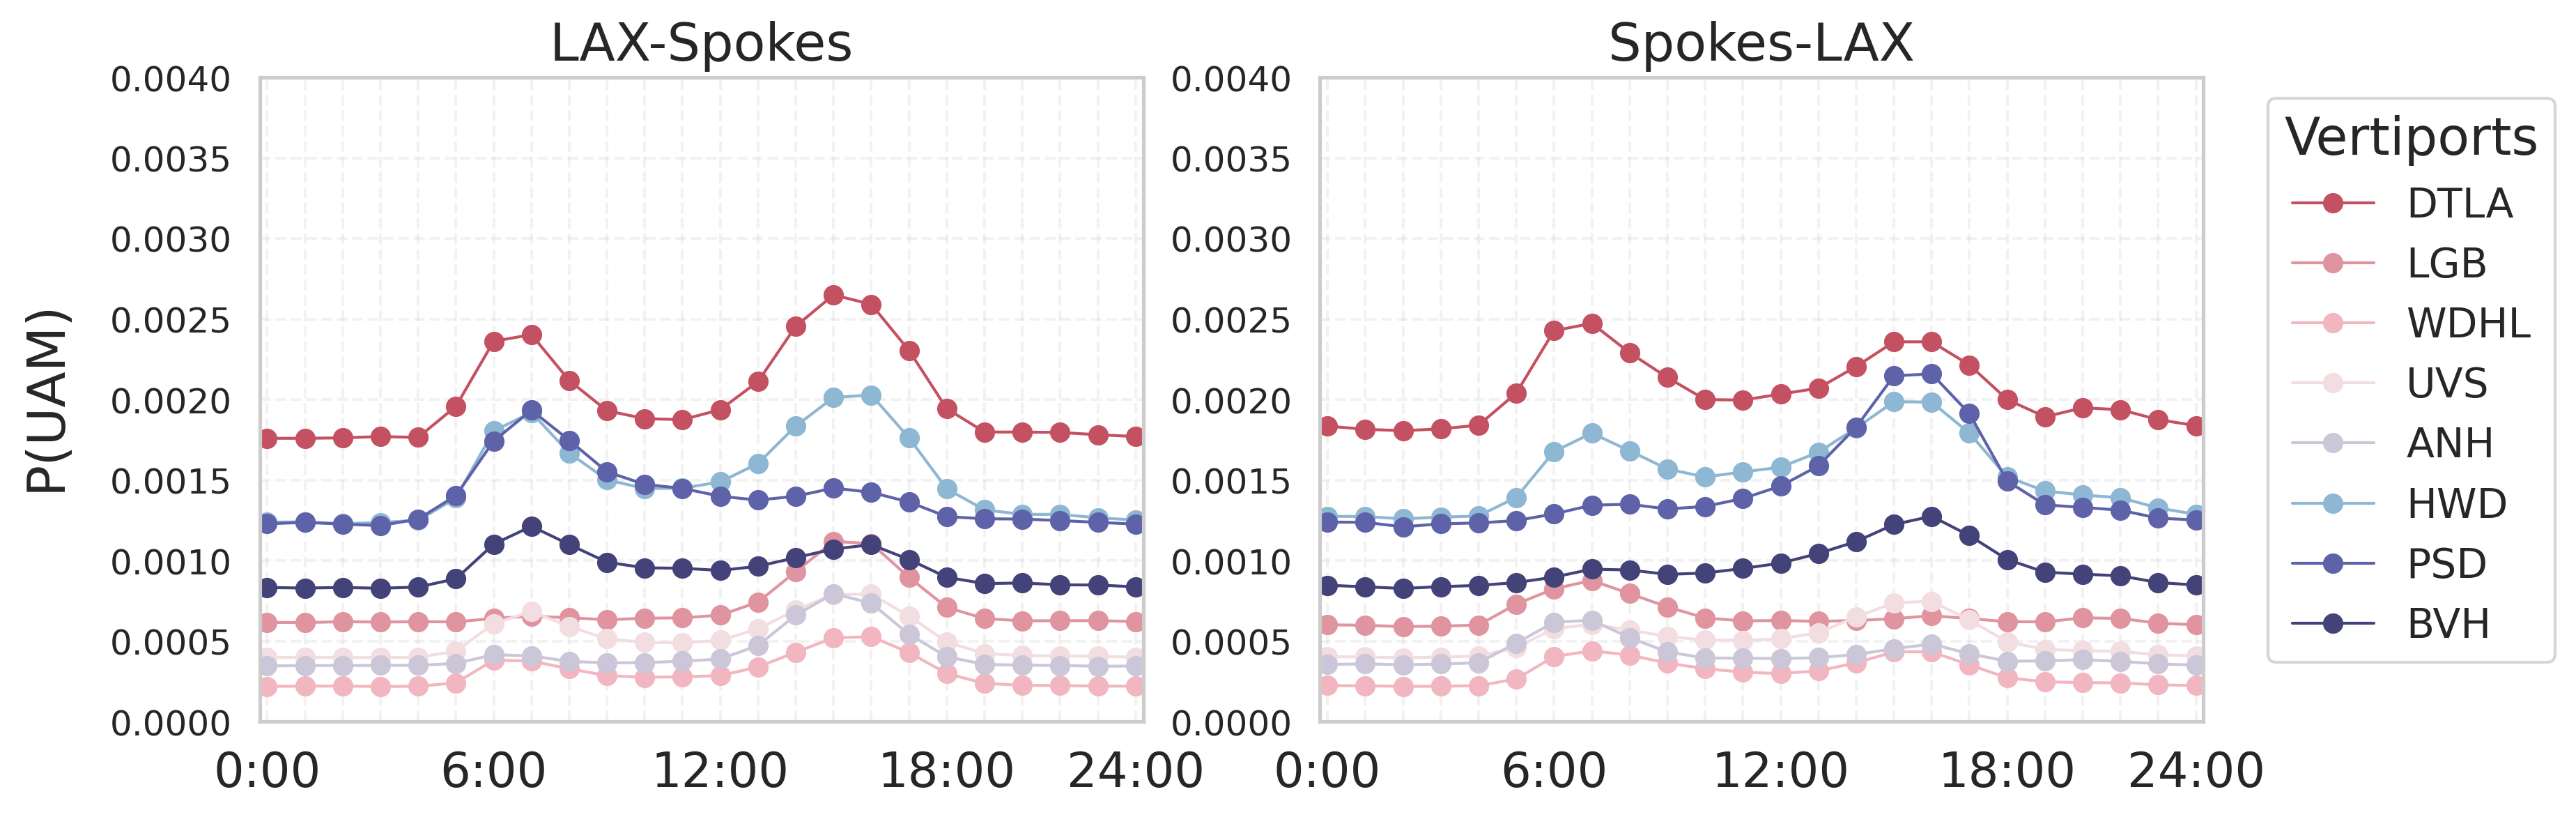

In [6]:
fig, ax = plot_travel_time(p_uam_array, vertiports, ylim=(0, 0.004), ylabel=r"")
for i in range(2):
    ax[i].tick_params(axis='y', labelsize=12)
fig.text(
    0.04, 0.5, "P(UAM)", ha="center", va="center", rotation="vertical"
);

In [7]:
p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])
network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
    seed=9,
)

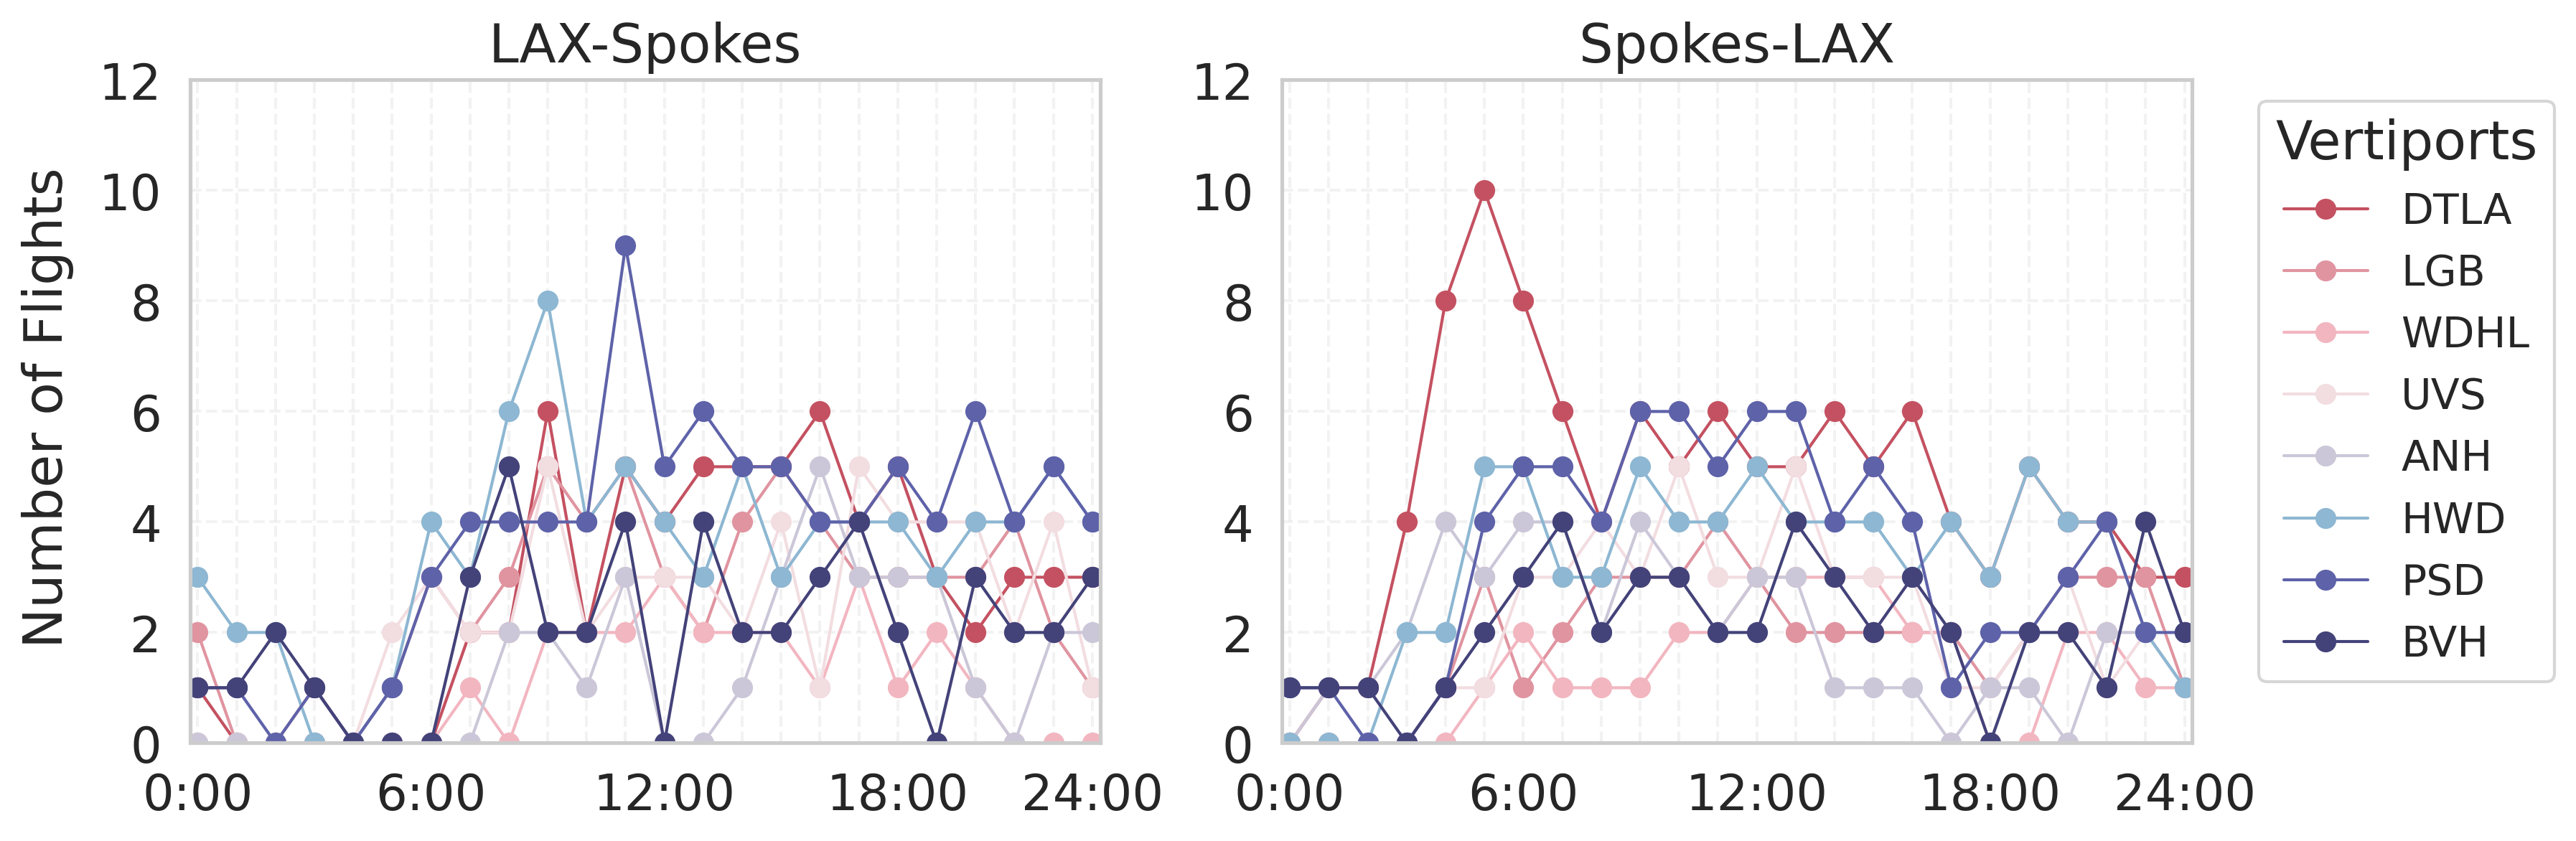

In [8]:
network.plot_flight(ylim=(0, 12));

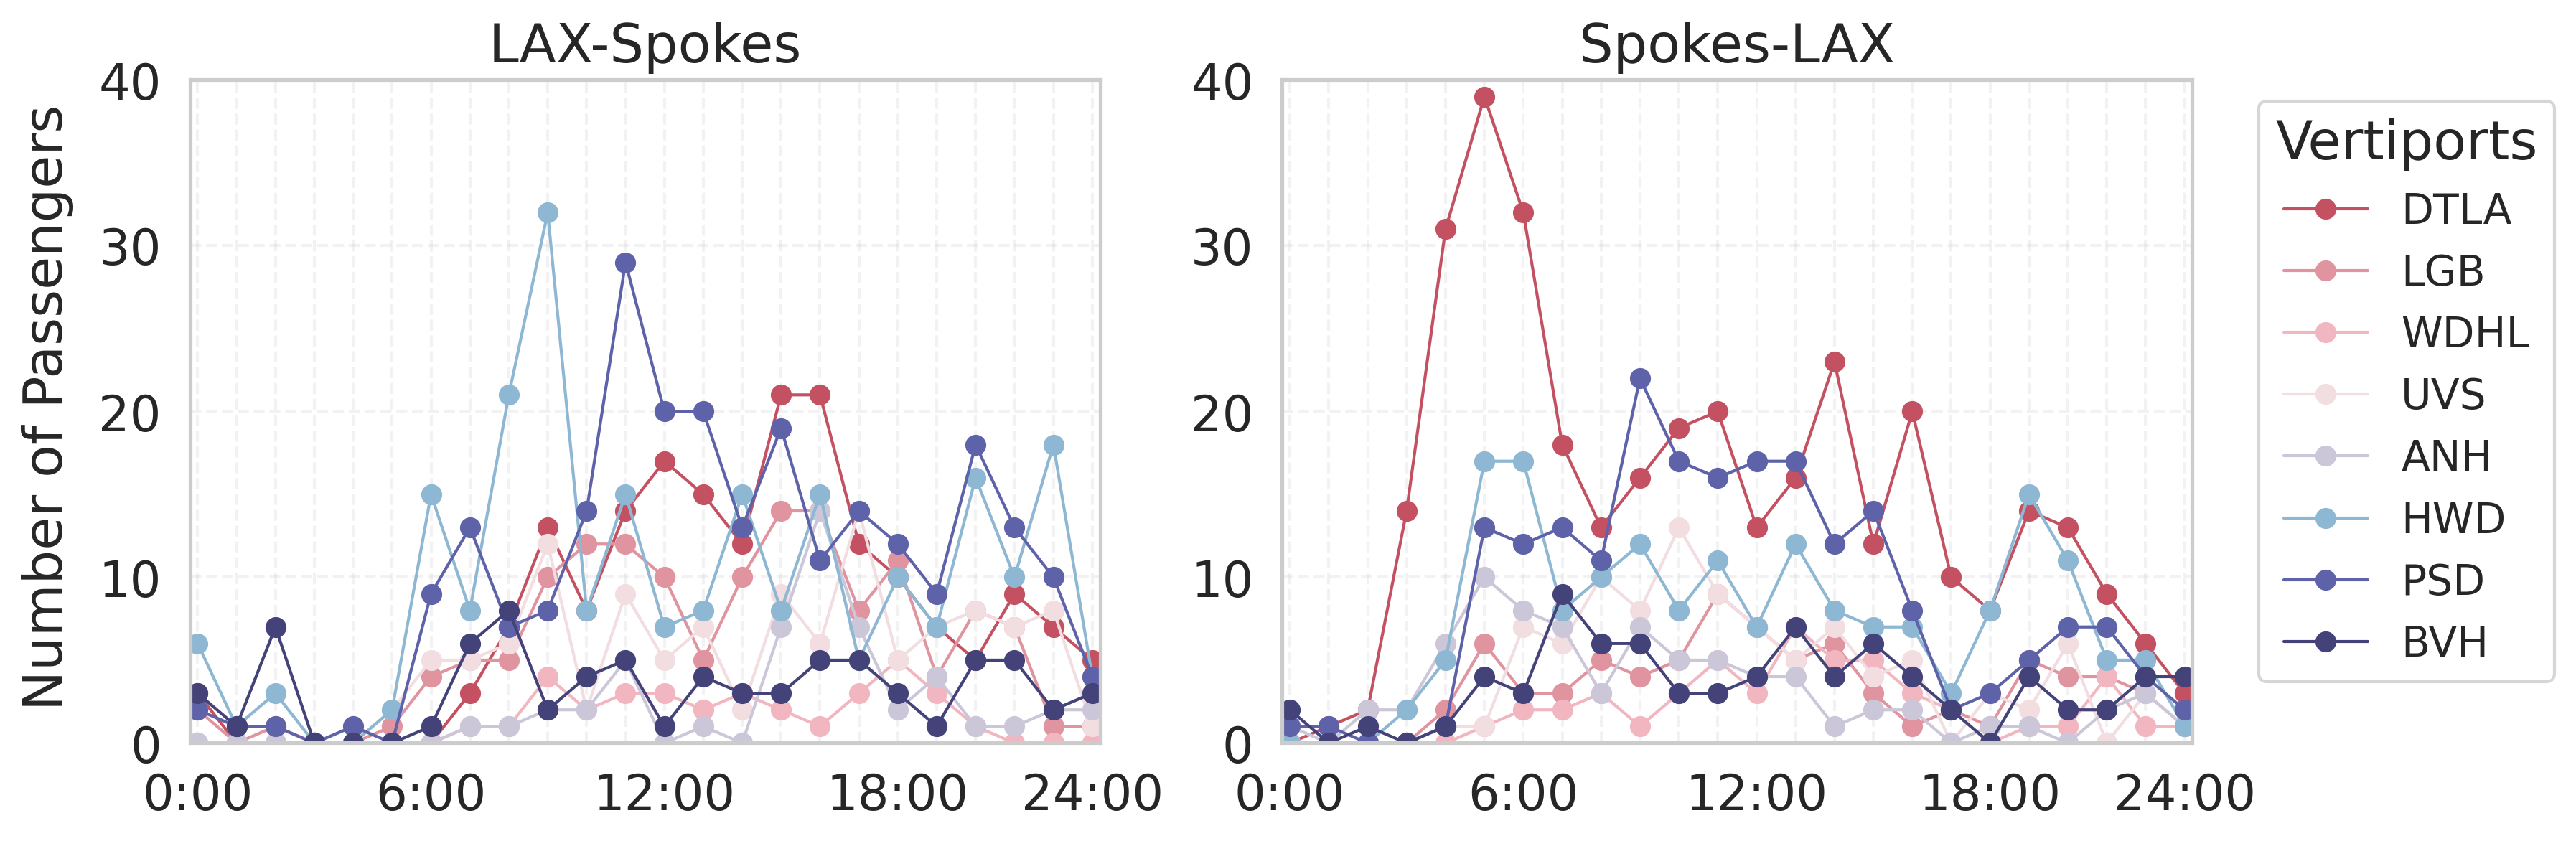

In [9]:
network.plot_pax(ylim=(0, 40));

## !! working

In [10]:
SURVEY_P_TNC = 0.33327  # from the recorded data

total_seat = network.demand_generator.yearly_capacity[0] + network.demand_generator.yearly_capacity[1]
OD_PAX_TO_SEAT_RATIO = 77500000 / total_seat # from the recorded data

VERTIPORT_PMF = np.array([0, 3.8, 2.4, 1, 1, 4.1, 2.5, 2.2, 1.5])/ 100 # from passenger origin survey data

vertiport_density = np.zeros((len(VERTIPORT_PMF), len(VERTIPORT_PMF)))
vertiport_density[0, :] = VERTIPORT_PMF
vertiport_density[:, 0] = VERTIPORT_PMF

p_uam_array = 1 * SURVEY_P_TNC * OD_PAX_TO_SEAT_RATIO
p_uam_array = p_uam_array * (np.repeat(vertiport_density[:, :, np.newaxis], 24, axis=2))

p_uam_array = np.concatenate([[p_uam_array[0,:,:] , p_uam_array[:,0,:]]])
network.load_demand(
    month=9,
    day=5,
    vertiport_pmf=p_uam_array,
    max_waiting_time=10,
    auto_regressive_alpha=0.7,
    seed=9,
)

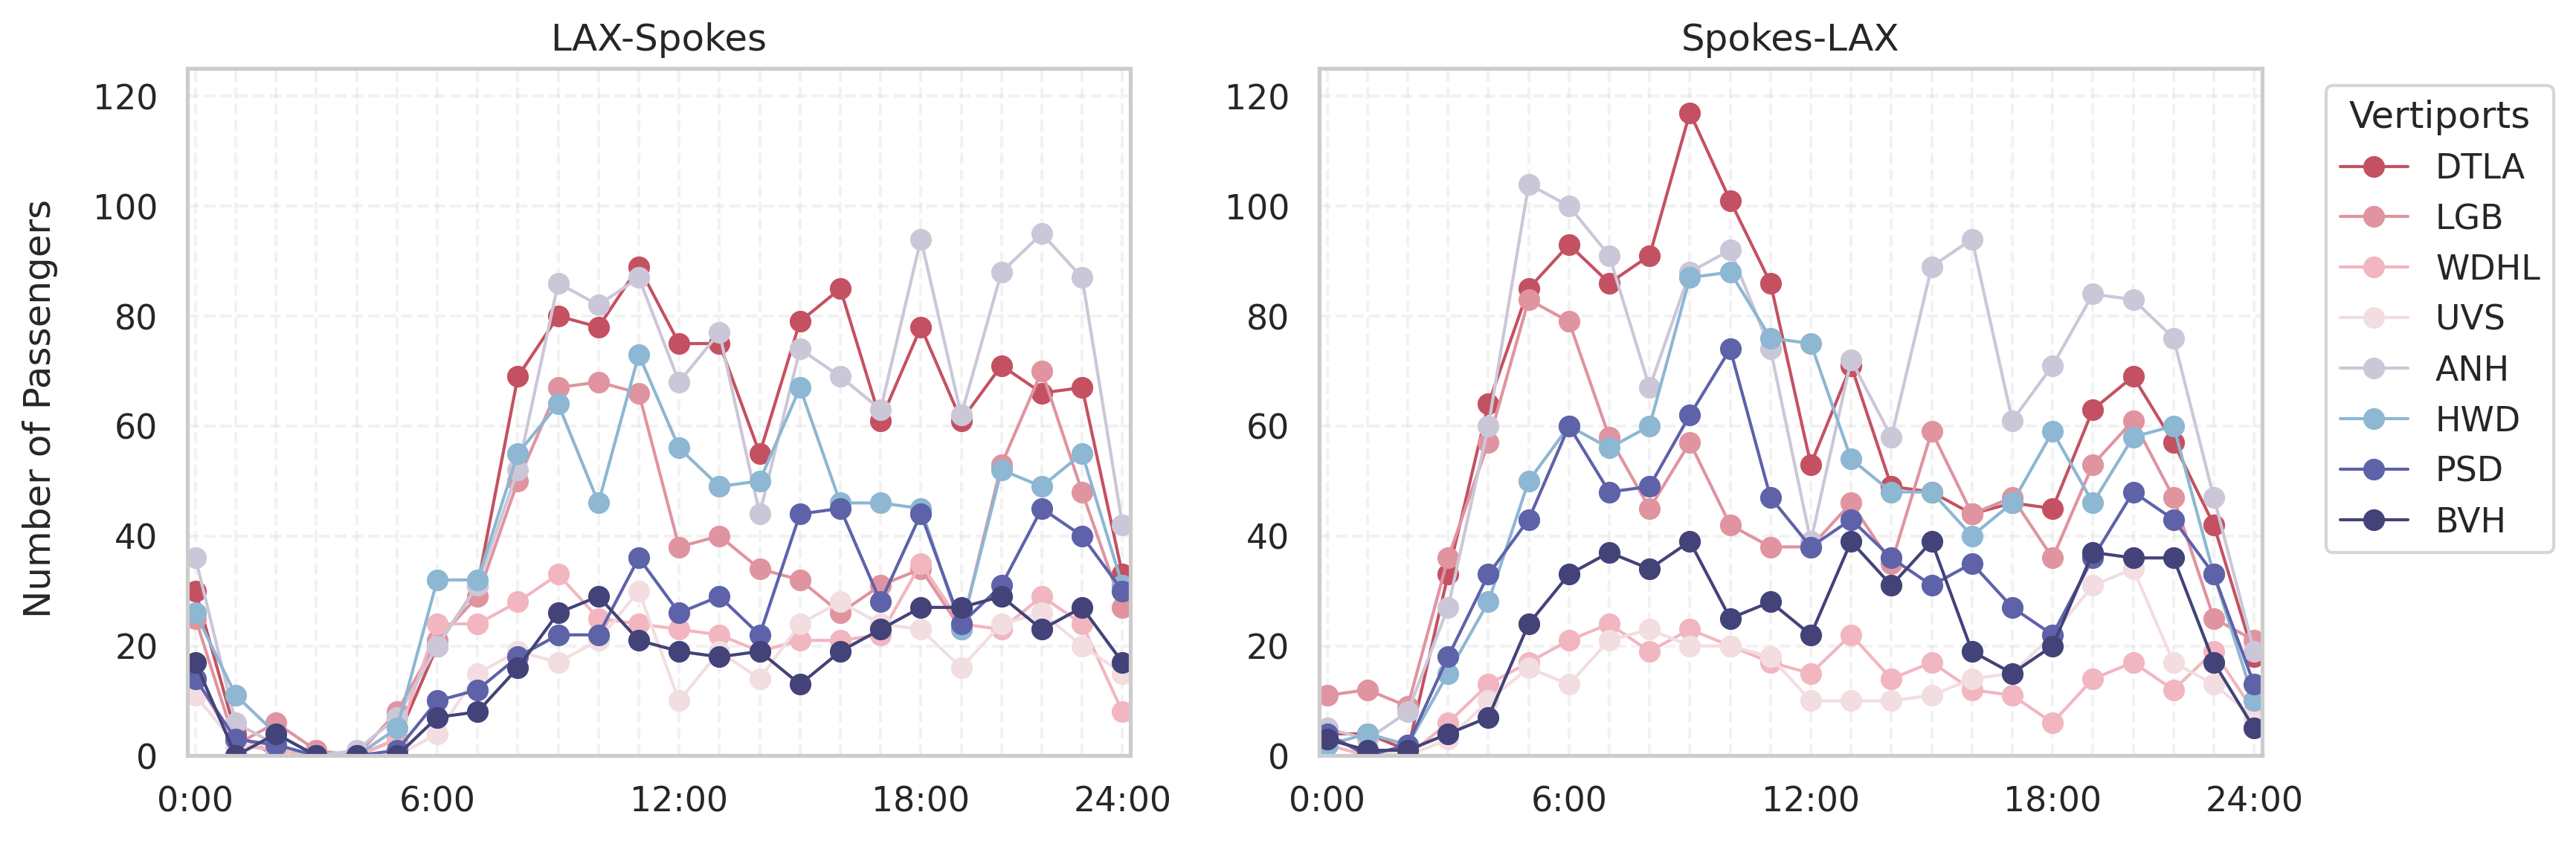

In [221]:
network.plot_pax(ylim=(0, 125));

In [11]:
time_resolution = 30  # 15 minutes in seconds

pax_arr = network.pax_arrival_times.copy()

pax_arr['passenger_arrival_time_slot'] = np.ceil(pax_arr['passenger_arrival_time_s'] / time_resolution / 60).astype(int)
pax_arr_grouped = pax_arr.groupby(['origin_vertiport_id', 'destination_vertiport_id', 'passenger_arrival_time_slot']).size().reset_index(name='counts')
pax_arr_grouped = pax_arr_grouped.sort_values(by=["passenger_arrival_time_slot"]).reset_index(drop=True)
pax_arr_grouped 

,origin_vertiport_id,destination_vertiport_id,passenger_arrival_time_slot,counts
0,0,1,0,1
1,0,1,1,10
2,0,2,1,14
3,6,0,1,1
4,0,3,1,11
...,...,...,...,...
697,0,6,48,17
698,0,8,48,12
699,4,0,48,4
700,1,0,48,9


In [14]:
flight_time_matrix = np.ceil(network.flight_time * 5 / time_resolution)

all_tasks = []
for idx, row in pax_arr_grouped.iterrows():
    all_tasks.append(
        FlightTask(
            name=f"Task_{idx}",
            start_time=row['passenger_arrival_time_slot'],
            duration=flight_time_matrix[row['origin_vertiport_id'], row['destination_vertiport_id']],
            origin=row['origin_vertiport_id'],
            destination= row['destination_vertiport_id'],
            flight_time_matrix=flight_time_matrix,
            num_pax=row['counts']
        )
    )

assignment_network = AssignmentNetwork(all_tasks, num_vehicles=35)
nodes, supply, edges, di_bar, c = assignment_network.populate_network()



In [16]:
import pickle
with open("travel_time.pkl", "rb") as file:
    uber_travel_time, _, _, _ = pickle.load(file)


flight_time_matrix = np.load("../UAM-System-Model/uam_system_model/data/config/flight_time_matrix.npy") * 5


uber_travel_time_i = []
uber_fare = np.array([0, 50, 62, 78, 57, 77, 57, 57, 45])
uber_fare_i = []

t_i_uam = []
flight_cost_uam = []

for idx, row in pax_arr_grouped.iterrows():
    origin = row['origin_vertiport_id']
    destination = row['destination_vertiport_id']
    time = row['passenger_arrival_time_slot']
    time = np.ceil(time /(60/time_resolution)).astype(int)-1

    t_i_uam.append(flight_time_matrix[origin, destination]+10)

    uber_travel_time_i.append(uber_travel_time[origin, destination, time])

    od_idx = max(origin, destination)
    uber_fare_i.append(uber_fare[od_idx])

    distance = distance_matrix[origin, destination]
    flight_cost_uam.append(0.79 * 4 * distance)

    
uber_travel_time_i = np.array(uber_travel_time_i)
uber_fare_i = np.array(uber_fare_i)

t_i_uam = np.array(t_i_uam)

In [17]:
value_of_time = 32.63/60  # dollar per minute

non_zero_indices = [i for i, value in enumerate(di_bar) if value != 0]

di_bar_selected_x = [di_bar[i] for i in non_zero_indices]
p_i_bar = [1/value_of_time for _ in non_zero_indices]  # 32.63 is the VOT in dollars per minute

# v_i_bar_uber = -uber_travel_time - p_i_bar * uber_fare + ASC_uber
v_i_bar_uber =  - uber_travel_time_i - p_i_bar * uber_fare_i



In [18]:
bins = 10

m = Model("Pricing Problem")
m.Params.NonConvex = 2
m.setParam("MIPGap", 0.1)

m._x_vars = m.addVars(edges, vtype=GRB.INTEGER, name="x_ij")

m._theta_uam = m.addVars(len(non_zero_indices), vtype=GRB.CONTINUOUS, name="theta_uam", lb=0, ub=1)
m._theta_ln_theta_uam = m.addVars(len(non_zero_indices), vtype=GRB.CONTINUOUS, name="ln_theta_uam", lb=-float("inf"), ub=0)

m._theta_ln_1_minus_theta_uam = m.addVars(len(non_zero_indices), vtype=GRB.CONTINUOUS, name="1_minus_ln_theta_uam", lb=-float("inf"), ub=0)


eps = 1e-4
xs = [1/bins*i for i in range(bins+1)]
ys = [p*math.log(p) if p !=0 else 0 for p in xs]
ys2 = [p*math.log(1 - p) if p !=1 else 0 for p in xs]

for i in range(len(non_zero_indices)):
    m.addGenConstrPWL(m._theta_uam[i], m._theta_ln_theta_uam[i], xs, ys, name=f"pwl_{i}")
    m.addGenConstrPWL(m._theta_uam[i], m._theta_ln_1_minus_theta_uam[i], xs, ys2, name=f"pwl2_{i}")

# Flow conservation constraints
for n in tqdm(nodes):
    m.addConstr(
        sum(m._x_vars[i, j] for i, j in edges if j == n)
        - sum(m._x_vars[i, j] for i, j in edges if i == n)
        == supply.get(n, 0),
        f"node_{n}",
    )

# Capacity constraints
for i in range(len(non_zero_indices)):
    idx = non_zero_indices[i]
    m.addConstr(
        m._x_vars[edges[idx]] * 4 >= m._theta_uam[i] * di_bar_selected_x[i], f"cap_{i}"
    )

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-30
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.1


100%|██████████| 1406/1406 [00:28<00:00, 48.65it/s]


In [19]:
operating_cost = quicksum(m._x_vars[edges[i]] * flight_cost_uam[i_non_zero] for i_non_zero, i in zip(range(len(di_bar_selected_x)), non_zero_indices))
theta_terms = quicksum(
    di_bar_selected_x[i_non_zero] / p_i_bar[i_non_zero] * (m._theta_ln_theta_uam[i_non_zero] - m._theta_ln_1_minus_theta_uam[i_non_zero]) for i_non_zero in range(len(di_bar_selected_x)) 
)

other_terms = quicksum(
    di_bar_selected_x[i_non_zero] / p_i_bar[i_non_zero] * m._theta_uam[i_non_zero] * (v_i_bar_uber[i_non_zero] + t_i_uam[i_non_zero]) for i_non_zero in range(len(di_bar_selected_x))
)

objective = theta_terms + other_terms + operating_cost

m.setObjective(objective, GRB.MINIMIZE)
m.update()
m.optimize()

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 32 threads

Optimize a model with 2108 rows, 237826 columns and 472844 nonzeros
Model fingerprint: 0xa7e011b7
Model has 1404 general constraints
Variable types: 2106 continuous, 235720 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+01]
  Objective range  [5e-01, 6e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e+01, 4e+01]
  PWLCon x range   [1e-01, 9e-01]
  PWLCon y range   [1e-02, 2e+00]
Presolve added 2760 rows and 13992 columns
Presolve time: 0.63s
Presolved: 4868 rows, 251818 columns, 503659 nonzeros
Presolved model has 1404 SOS constraint(s)
Variable types: 16146 continuous, 235672 integer (0 binary)
Deterministic concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Root barrier log.

In [22]:
results = []
for v in m.getVars():
    if v.X > 0.01:
        results.append((v.VarName, v.X))
results = pd.DataFrame(results, columns=["Variable", "Value"])
prices = results[results["Variable"].str.contains("theta_uam")].reset_index(drop=True)
prices['flight_index'] = prices['Variable'].apply(lambda x: int(re.findall(r'\d+', x)[0]))
prices['percentage_uam'] = prices['Value'].astype(float)
prices['fare'] = prices.apply(lambda row: calc_fare(row, value_of_time, v_i_bar_uber, t_i_uam), axis=1)

prices = prices[['flight_index', 'percentage_uam', 'fare']]
flow = results[results["Variable"].str.contains("x_ij")]

pattern = r"x_ij\[\('Task_\d+', 'start'\)"
flow = flow[flow["Variable"].str.contains(pattern)].reset_index(drop=True)
flow['flight_index'] = flow['Variable'].apply(lambda x: int(re.findall(r'Task_(\d+)', x)[0]))
flow = flow[['flight_index', 'Value']]
flow = flow.rename(columns={'Value': 'num_flights'})

output_merged = prices.merge(flow, on='flight_index', how='left')
output_merged

,flight_index,percentage_uam,fare,num_flights
0,0,1.000000,46.677048,1.0
1,1,0.800000,50.496904,2.0
2,2,0.857143,62.222015,3.0
3,3,1.000000,56.994431,1.0
4,4,1.000000,76.689231,3.0
...,...,...,...,...
472,696,1.000000,56.776898,2.0
473,697,0.941176,60.005990,4.0
474,699,1.000000,58.462781,1.0
475,700,0.888889,51.533914,2.0


In [213]:
pax_arr_grouped_to_join = pax_arr_grouped.copy()
pax_arr_grouped_to_join['flight_index'] = pax_arr_grouped_to_join.index
pax_arr_grouped_to_join = pax_arr_grouped_to_join.rename(columns={'counts': 'num_pax'})

df = pd.merge(output_merged, pax_arr_grouped_to_join, on='flight_index', how='left')


# od_pairs = [(0, i) for i in range(1, 9)] + [(i, 0) for i in range(1, 9)]
# timeslots = pd.DataFrame(
#     [(od[0], od[1], t) for od in od_pairs for t in range(1, 24*60//time_resolution + 1)],
#     columns=["origin_vertiport_id", "destination_vertiport_id", "passenger_arrival_time_slot"]
# )

# df = pd.merge(timeslots, df, on=['origin_vertiport_id', 'destination_vertiport_id', 'passenger_arrival_time_slot'], how='left').fillna(0)


df['distance'] = df.apply(lambda row: distance_matrix[int(row['origin_vertiport_id']), int(row['destination_vertiport_id'])], axis=1)

df['uam_pax']= df['num_pax'] * df['percentage_uam']

df['rev_per_mile'] = df['fare'] / df['distance']

df['markets'] = df.apply(lambda row: int(max(row['origin_vertiport_id'], row['destination_vertiport_id'])), axis=1)
df['markets'] = df['markets'].apply(lambda x: network.vertiport_dict_inv[x])

df['rev_per_mile'] = df['fare'] / df['distance']
df['total_revenue'] = df['fare'] * df['uam_pax']

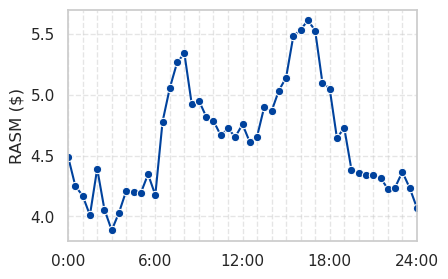

In [214]:
sns.set(style ="whitegrid", font_scale=1)


df_grouped = df.groupby(['passenger_arrival_time_slot'])['rev_per_mile'].mean()

fig, ax = plt.subplots(figsize=(4.5, 3), dpi=100)
sns.lineplot(x=np.arange(len(df_grouped)), y=df_grouped.values, marker='o', color=color[1], ax=ax)
ax.set(xticks=np.arange(0, 49, 12), 
       xticklabels=[str(i) + ":00" for i in range(0, 26, 6)],
       xlabel="", ylabel="RASM ($)", xlim=(0, 48));
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(True, linestyle='--', alpha=0.5)


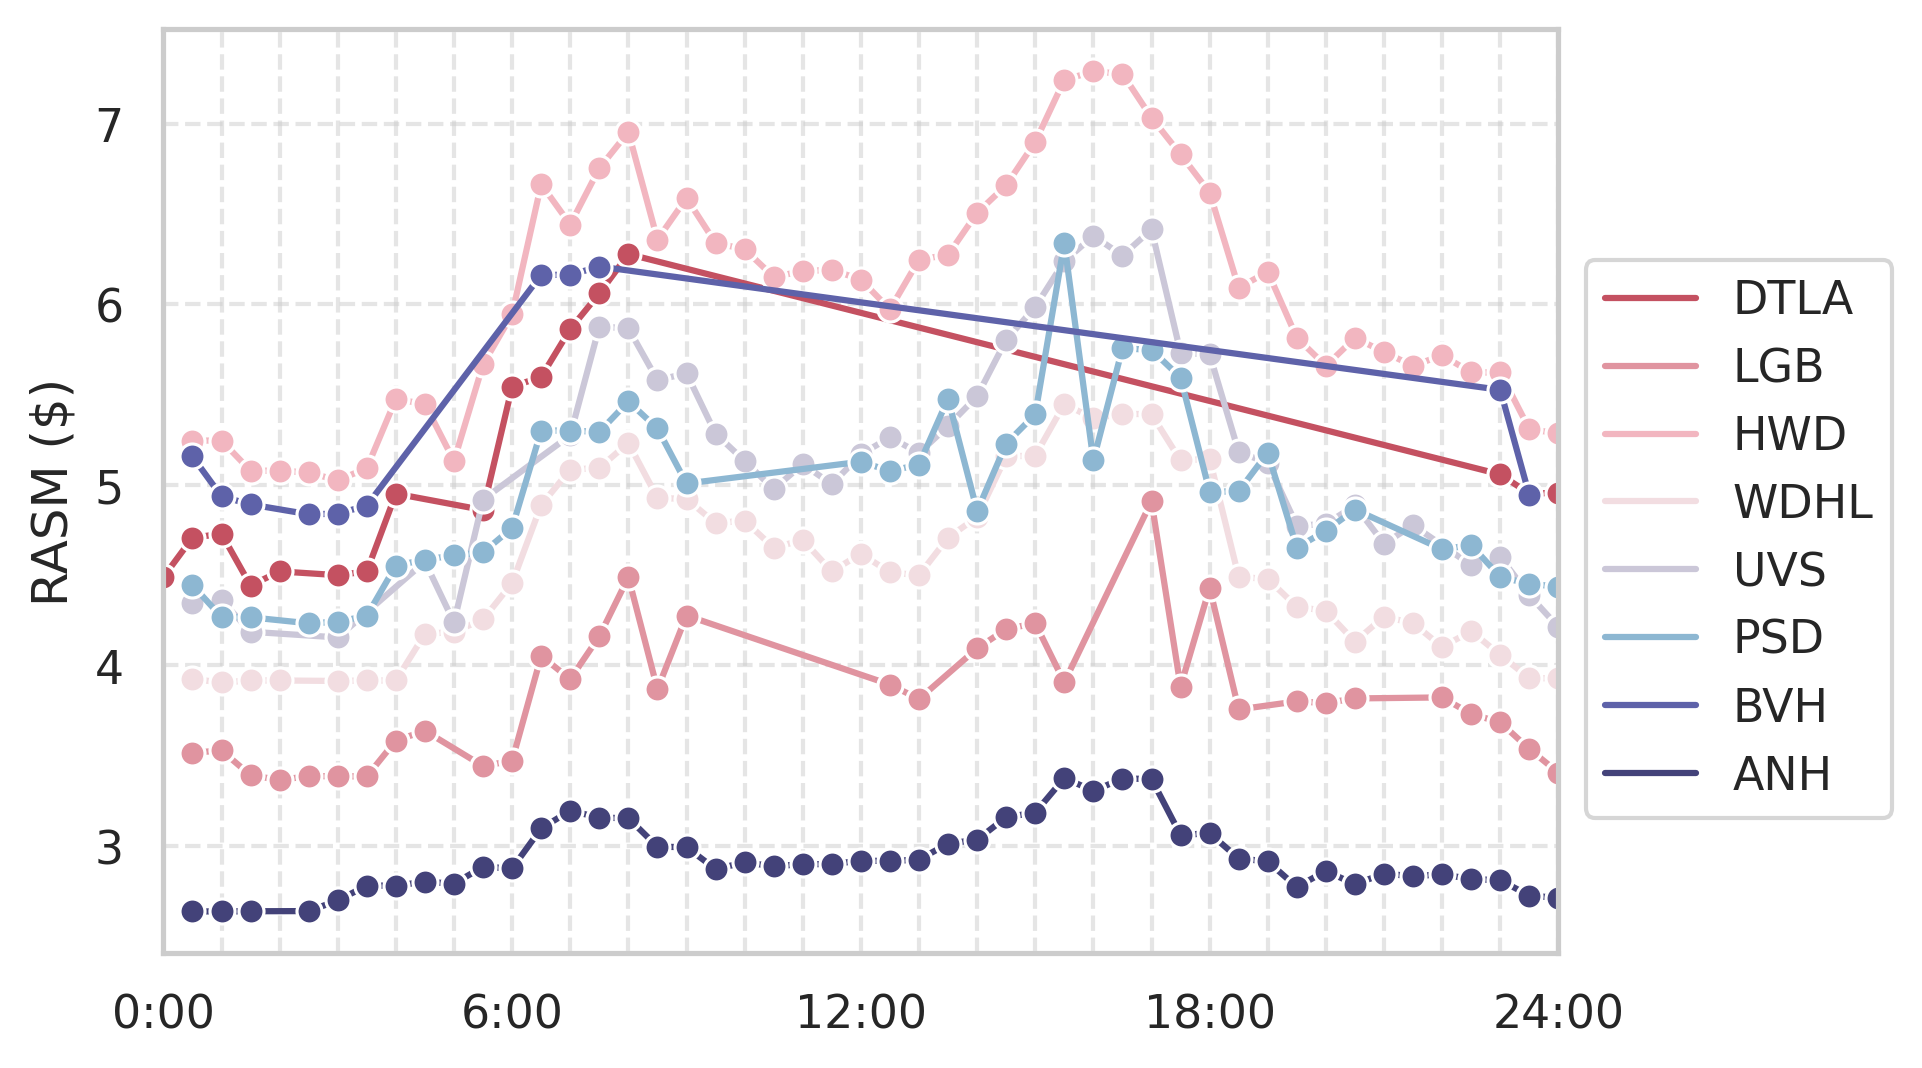

In [215]:
sns.set(style ="whitegrid", font_scale=1)


fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
sns.lineplot(data=df, x="passenger_arrival_time_slot", hue="markets", y="rev_per_mile", marker='o', err_style=None, palette=custom_colors, ax=ax)
ax.set(xticks=np.arange(0, 49, 12), 
       xticklabels=[str(i) + ":00" for i in range(0, 26, 6)],
       xlabel="", ylabel="RASM ($)", xlim=(0, 48));
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 0.75), loc='upper left', borderaxespad=0.)


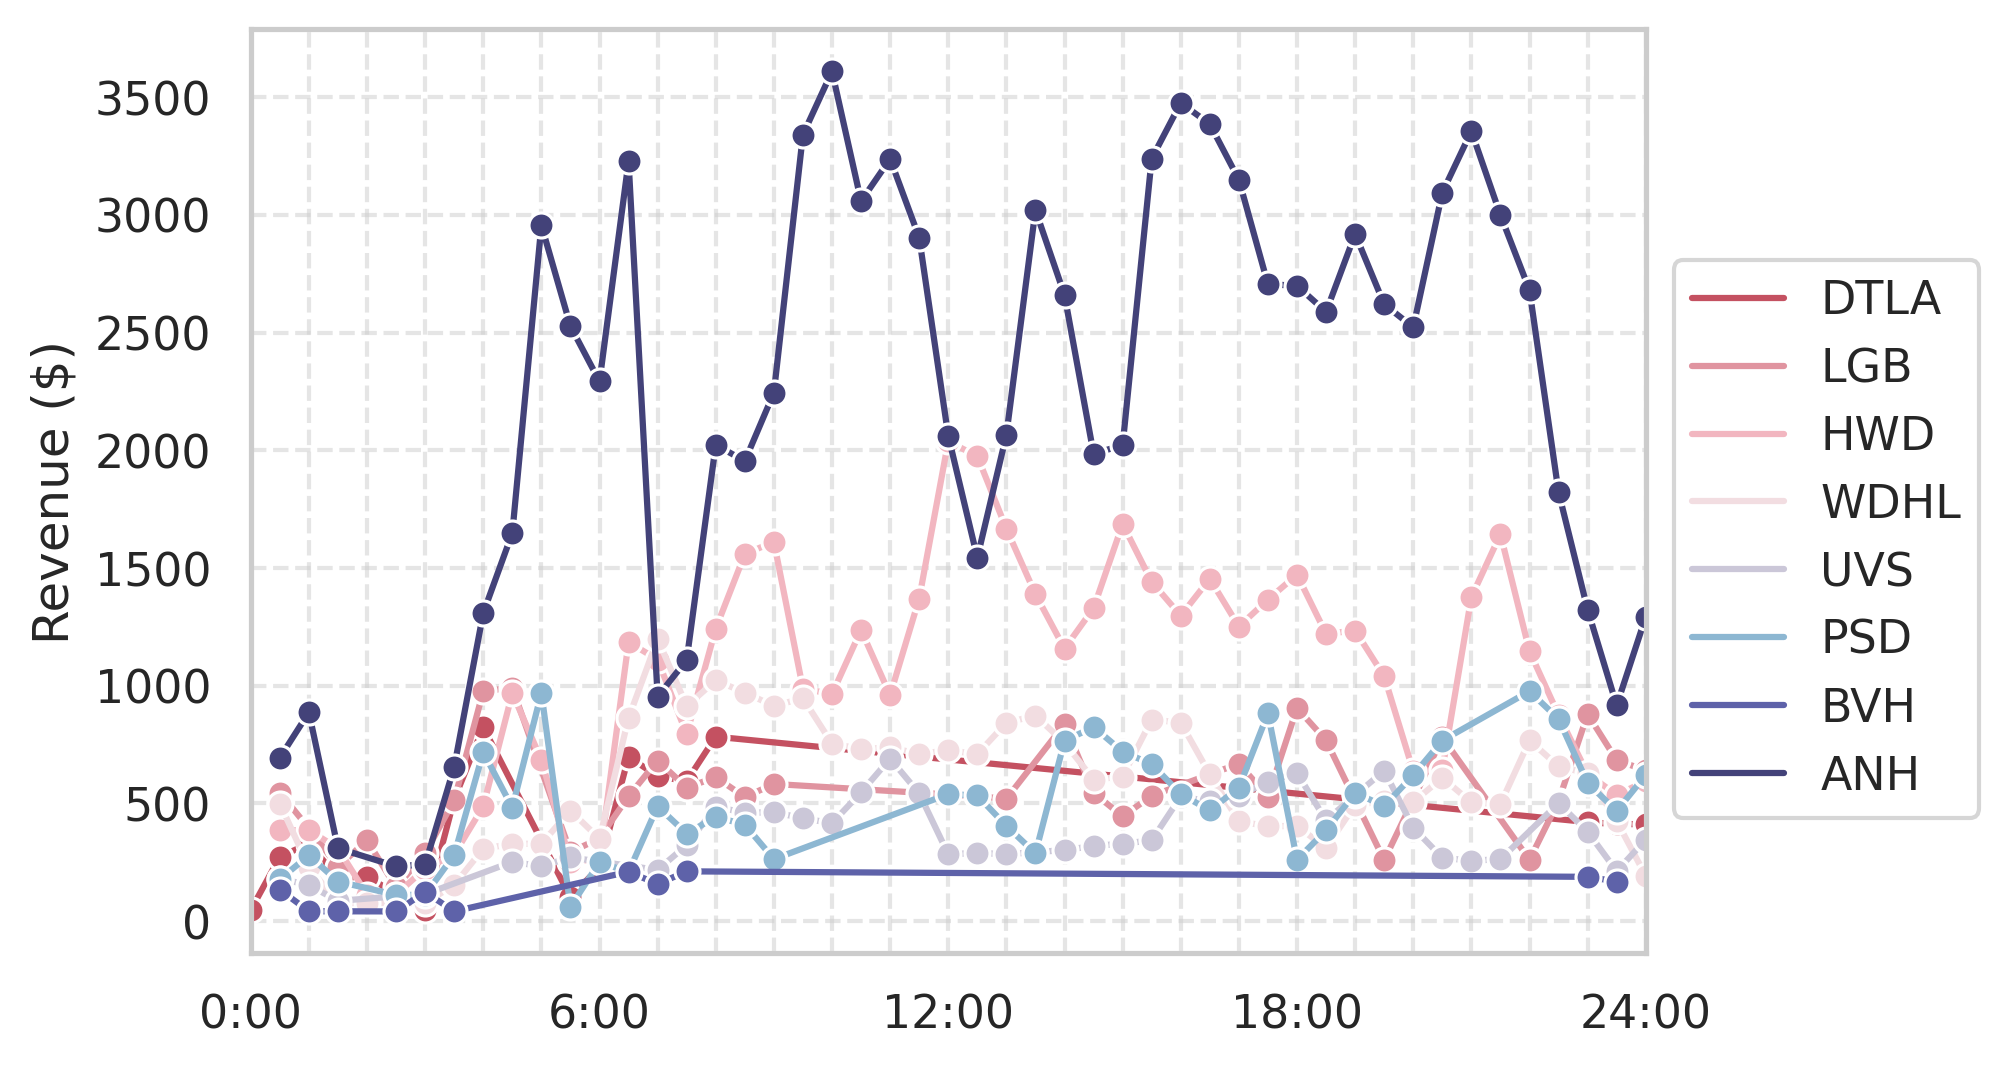

In [218]:
df['total_revenue'] = df['fare'] * df['uam_pax']

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
sns.lineplot(data=df, x="passenger_arrival_time_slot", y="total_revenue", hue="markets", err_style=None, legend=True, marker='o', palette=custom_colors, ax=ax)
ax.set(xticks=np.arange(0, 49, 12), 
       xticklabels=[str(i) + ":00" for i in range(0, 26, 6)],
       xlabel="", ylabel="Revenue ($)", xlim=(0, 48));
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 0.75), loc='upper left', borderaxespad=0.)

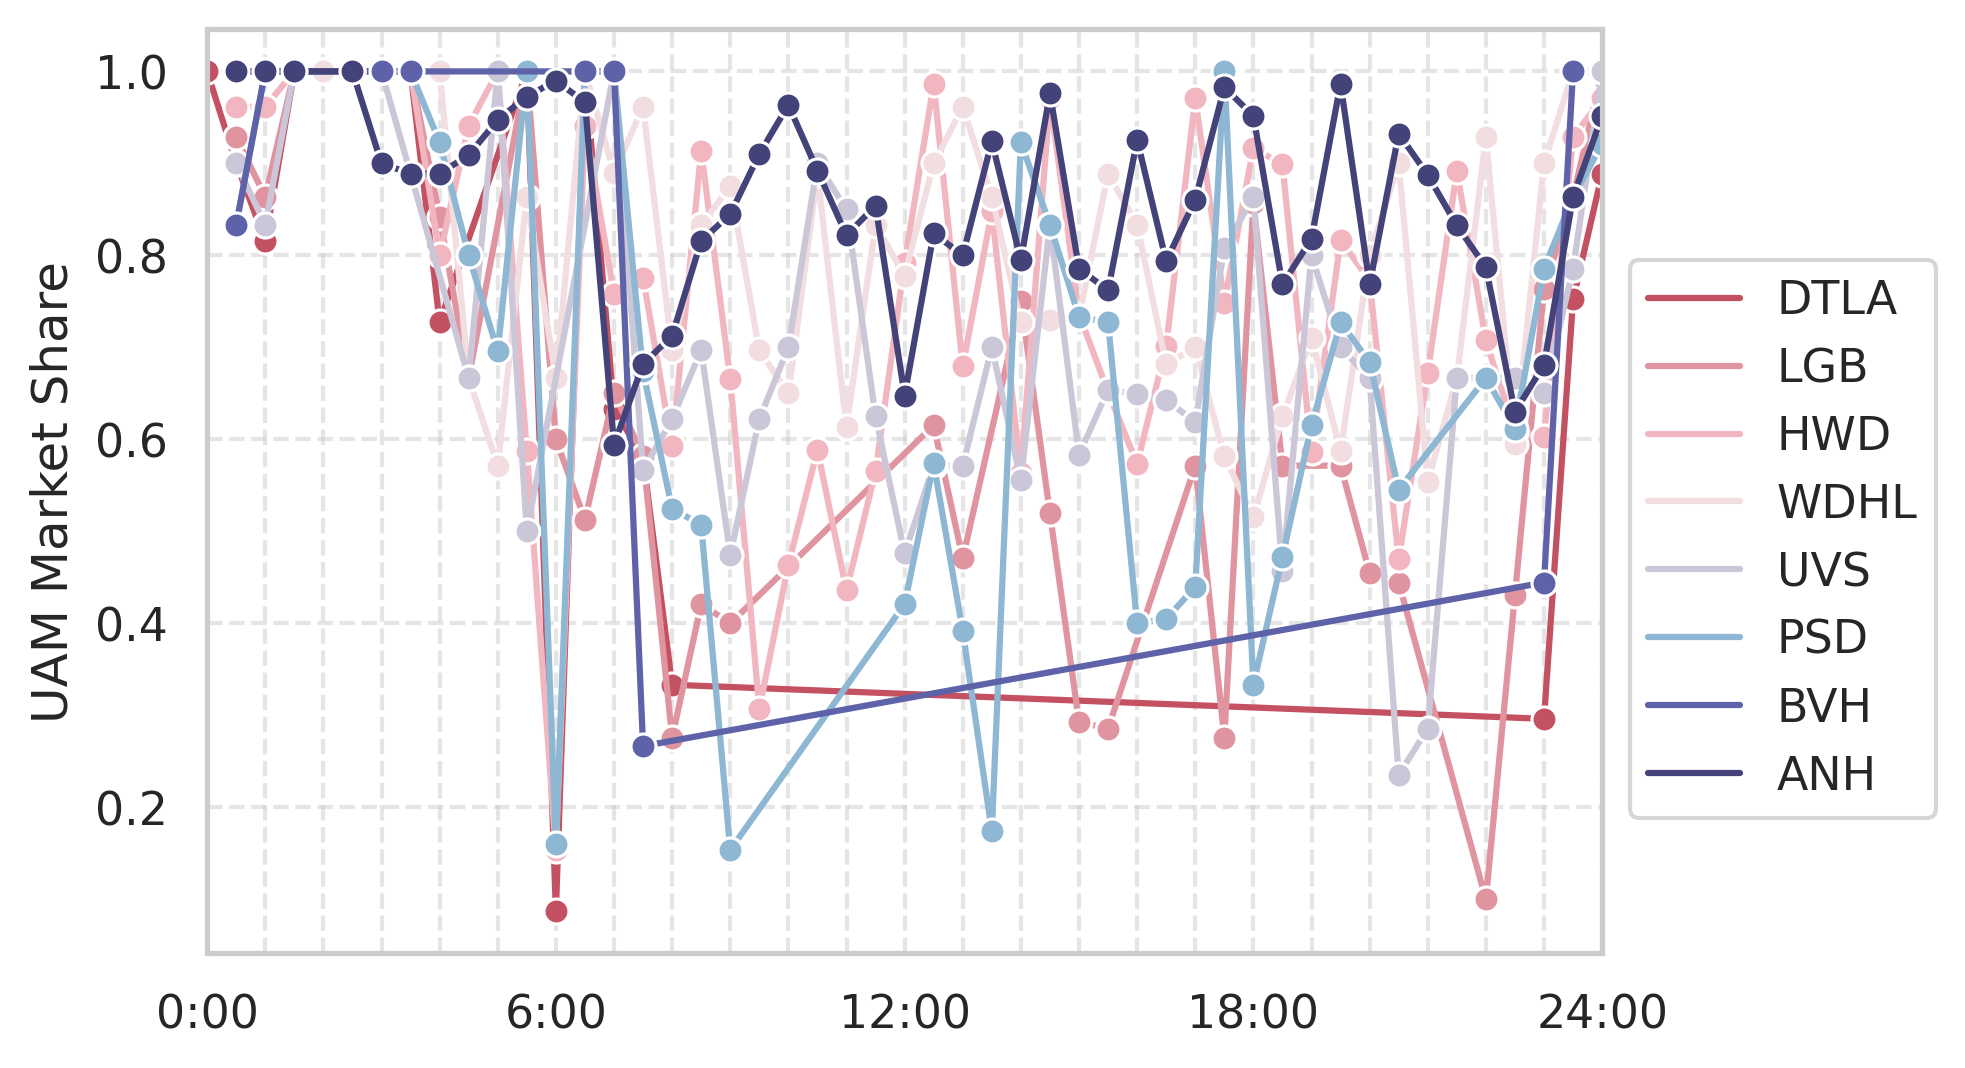

In [217]:


fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
sns.lineplot(data=df, x="passenger_arrival_time_slot", y="percentage_uam", hue="markets", err_style=None, legend=True, marker='o', palette=custom_colors, ax=ax)
ax.set(xticks=np.arange(0, 49, 12), 
       xticklabels=[str(i) + ":00" for i in range(0, 26, 6)],
       xlabel="", ylabel=r"UAM Market Share", xlim=(0, 48));
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 0.75), loc='upper left', borderaxespad=0.)


In [21]:
def calc_fare(row, value_of_time, v_i_bar_uber, t_i_uam):
    theta = row['Value']
    index = row['flight_index']
    if theta >= 1:
        theta = 0.9999
    if theta <= 0:
        theta = 0.0001



    fare = -value_of_time * (math.log(theta) - math.log(1-theta) + v_i_bar_uber[index] + t_i_uam[index])
    return fare



,Variable,Value,flight_demand_i
0,"x_ij[('Task_0', 'start'),('Task_0', 'finish')]",0.250,0
1,"x_ij[('Task_1', 'start'),('Task_1', 'finish')]",0.250,1
2,"x_ij[('Task_2', 'start'),('Task_2', 'finish')]",3.500,2
3,"x_ij[('Task_3', 'start'),('Task_3', 'finish')]",0.250,3
4,"x_ij[('Task_4', 'start'),('Task_4', 'finish')]",2.750,4
...,...,...,...
456,"x_ij[('Task_696', 'start'),('Task_696', 'finis...",1.250,696
457,"x_ij[('Task_697', 'start'),('Task_697', 'finis...",4.250,697
458,"x_ij[('Task_699', 'start'),('Task_699', 'finis...",1.000,699
459,"x_ij[('Task_700', 'start'),('Task_700', 'finis...",2.250,700


,Variable_x,Value_x,flight_demand_i,fare,Variable_y,Value_y
0,theta_uam[0],1.000000,0,52.115381,"x_ij[('Task_0', 'start'),('Task_0', 'finish')]",0.250
1,theta_uam[1],0.100000,1,57.884074,"x_ij[('Task_1', 'start'),('Task_1', 'finish')]",0.250
2,theta_uam[2],1.000000,2,63.625931,"x_ij[('Task_2', 'start'),('Task_2', 'finish')]",3.500
3,theta_uam[3],1.000000,3,62.432764,"x_ij[('Task_3', 'start'),('Task_3', 'finish')]",0.250
4,theta_uam[4],1.000000,4,82.127564,"x_ij[('Task_4', 'start'),('Task_4', 'finish')]",2.750
...,...,...,...,...,...,...
455,theta_uam[696],1.000000,696,62.215231,"x_ij[('Task_696', 'start'),('Task_696', 'finis...",1.250
456,theta_uam[697],1.000000,697,61.943314,"x_ij[('Task_697', 'start'),('Task_697', 'finis...",4.250
457,theta_uam[699],1.000000,699,63.901114,"x_ij[('Task_699', 'start'),('Task_699', 'finis...",1.000
458,theta_uam[700],1.000000,700,53.094281,"x_ij[('Task_700', 'start'),('Task_700', 'finis...",2.250


In [232]:
prices

,Variable,Value,flight_demand_i,fare
0,theta_uam[0],1.000000,0,52.115381
1,theta_uam[1],0.100000,1,57.884074
2,theta_uam[2],1.000000,2,63.625931
3,theta_uam[3],1.000000,3,62.432764
4,theta_uam[4],1.000000,4,82.127564
...,...,...,...,...
455,theta_uam[696],1.000000,696,62.215231
456,theta_uam[697],1.000000,697,61.943314
457,theta_uam[699],1.000000,699,63.901114
458,theta_uam[700],1.000000,700,53.094281


In [109]:
t_i_uam[1]

10

In [113]:
prices['fare']

0             NaN
1      478.996329
2      479.265479
3             NaN
4             NaN
          ...    
482           NaN
483           NaN
484           NaN
485           NaN
486    636.094329
Name: fare, Length: 487, dtype: float64

In [129]:
len(non_zero_indices)

1344

In [ ]:
m.optimize()

882008

In [ ]:
seq1 = [1, 2, 3]
seq2 = ['a', 'b', 'c']

for i, j in zip(seq1, seq2):
    print(f"i: {i}, j: {j}")

In [13]:

class FlightTask:
    def __init__(
        self,
        name,
        start_time,
        duration,
        origin,
        destination,
        flight_time_matrix,
        num_pax
    ):
        self.name = name
        self.start_time = start_time
        self.duration = duration
        self.land_time = self.start_time + self.duration
        self.flight_time_matrix = flight_time_matrix
        self.origin = origin
        self.destination = destination
        self.num_pax = num_pax


    def next_task(self, next_task):
        reposition_time = self.flight_time_matrix[self.destination, next_task.origin]

        next_task_start_time = next_task.start_time

        prep_time = 0

        ready_time = (
            self.land_time
            + self.flight_time_matrix[self.destination, next_task.origin]
            + prep_time
        )

        if ready_time <= next_task_start_time:
            return True
        else:
            return False


class AssignmentNetwork:
    def __init__(self, list_of_tasks, num_vehicles):
        self.list_of_tasks = list_of_tasks
        self.num_vehicles = num_vehicles

    def populate_network(self):
        nodes, supply = self._create_nodes()
        edge, di_bar, c = self._create_edges()

        return nodes, supply, edge, di_bar, c

    def _create_nodes(self):
        base_nodes = ["Source", "Sink"]
        assignment_nodes = [
            (task.name, status)
            for task in self.list_of_tasks
            for status in ["start", "finish"]
        ]
        nodes = base_nodes + assignment_nodes
        supply = {"Source": -self.num_vehicles, "Sink": self.num_vehicles}

        return nodes, supply

    def _create_edges(self):
        edge, di_bar = self._create_basic_edges()
        edge_reassignment, di_bar_reassignment = self._create_reassignment_edges()

        edge = edge + edge_reassignment
        di_bar = di_bar + di_bar_reassignment

        return edge, di_bar, dict(zip(edge, di_bar))

    def _create_basic_edges(self):
        di_bar = []
        source_to_task = [
            ("Source", (task.name, "start")) for task in self.list_of_tasks
        ]
        di_bar = di_bar + [0 for _ in range(len(source_to_task))]
        task_to_sink = [((task.name, "finish"), "Sink") for task in self.list_of_tasks]
        di_bar = di_bar + [0 for _ in range(len(task_to_sink))]
        task_to_task = [
            ((task.name, "start"), (task.name, "finish")) for task in self.list_of_tasks
        ]
        di_bar = di_bar + [task.num_pax for task in self.list_of_tasks]
        basic_edges = source_to_task + task_to_sink + task_to_task

        return basic_edges, di_bar

    def _create_reassignment_edges(self):
        reassignment_edges = []
        di_bar = []
        number_of_tasks = len(self.list_of_tasks)

        for i in range(number_of_tasks):
            for j in range(i + 1, number_of_tasks):
                if_connect = self.list_of_tasks[
                    i
                ].next_task(self.list_of_tasks[j])
                if if_connect:
                    reassignment_edges.append(
                        (
                            (self.list_of_tasks[i].name, "finish"),
                            (self.list_of_tasks[j].name, "start"),
                        )
                    )

                    di_bar.append(0)

        return reassignment_edges, di_bar


## !! end

### Optimization models

#### Validate fleet size with IP

In [141]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

ip = FleetSizeOptimizer(network)
network_fleet_size = []
for i in range(1, 9):
    fleetsize, policy = ip.optimize(vertiport_index=i,
                                    verbose=True, 
                                    optimality_gap=0.05, 
                                    n_threads=24)
    network_fleet_size.append(fleetsize)
    policy.to_csv(f"output/ECO_IP_WAIT10_FARE3/ip_policy_{i}.csv")
                                    

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-30
Set parameter Threads to value 24
Set parameter MIPGap to value 0.05
Set parameter FeasibilityTol to value 1e-05
Set parameter TimeLimit to value 1800
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 24 threads

Optimize a model with 21700 rows, 349272 columns and 685852 nonzeros
Model fingerprint: 0xf1d17077
Variable types: 0 continuous, 349272 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-05, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+00]
Presolve removed 2447 rows and 32213 columns
Presolve time: 1.95s
Presolved: 19253 rows, 317059 columns, 637803 nonzeros
Variable types: 0 continuous, 317059 integer (1 binary)
Deterministic concurrent LP optimi

In [143]:
sum(network_fleet_size)

31

#### total number of seats x P(OD passenger) x P(OD) x P(TNC) x P(Mode Share)

#### P(OD) = 77.5M / 102243130.0 = 0.7580

#### Run IP

In [14]:
from uam_system_model.FleetSizeOp import FleetSizeOptimizer
from uam_system_model.utils.FleetSizeOpSummary import FleetSizeOpSummary

In [15]:
fs = []
for i in range(1,9):
    file = pd.read_csv(f"output/ECO_IP_WAIT10_FARE3/ip_policy_{i}.csv")
    summary = FleetSizeOpSummary(network, file)
    output = summary.get_summary_statistics()
    fs.append(output['fleet_size'])

In [16]:
np.array(fs).sum()
# summary.plot_aircraft_state()

31

### Analytics

In [11]:
from uam_system_model.utils.FleetOpVRPSummary import FleetOpVRPSummary

In [12]:
path = 'output/ECO_WAIT10_FARE3/'
list_of_files = os.listdir(path)
list_of_files = [file for file in list_of_files if not file.endswith('clustering.csv')]

policy_0 = pd.read_csv(path + list_of_files[0])
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

for file in tqdm(list_of_files[1:]):
    policy = pd.read_csv(path + file)
    summary = FleetOpVRPSummary(network, policy)
    statistics = summary.get_summary_statistics()
    df = pd.concat([df, pd.DataFrame([statistics])], ignore_index=True)

fs_idxmax = df.groupby("fleet_size")['number_of_revenue_flights'].idxmax()
df_max = df.loc[fs_idxmax].sort_values(by='fleet_size')
df_max = df_max[df_max['fleet_size']<=34]

100%|██████████| 16/16 [00:21<00:00,  1.36s/it]


#### Making fleet sizing decision


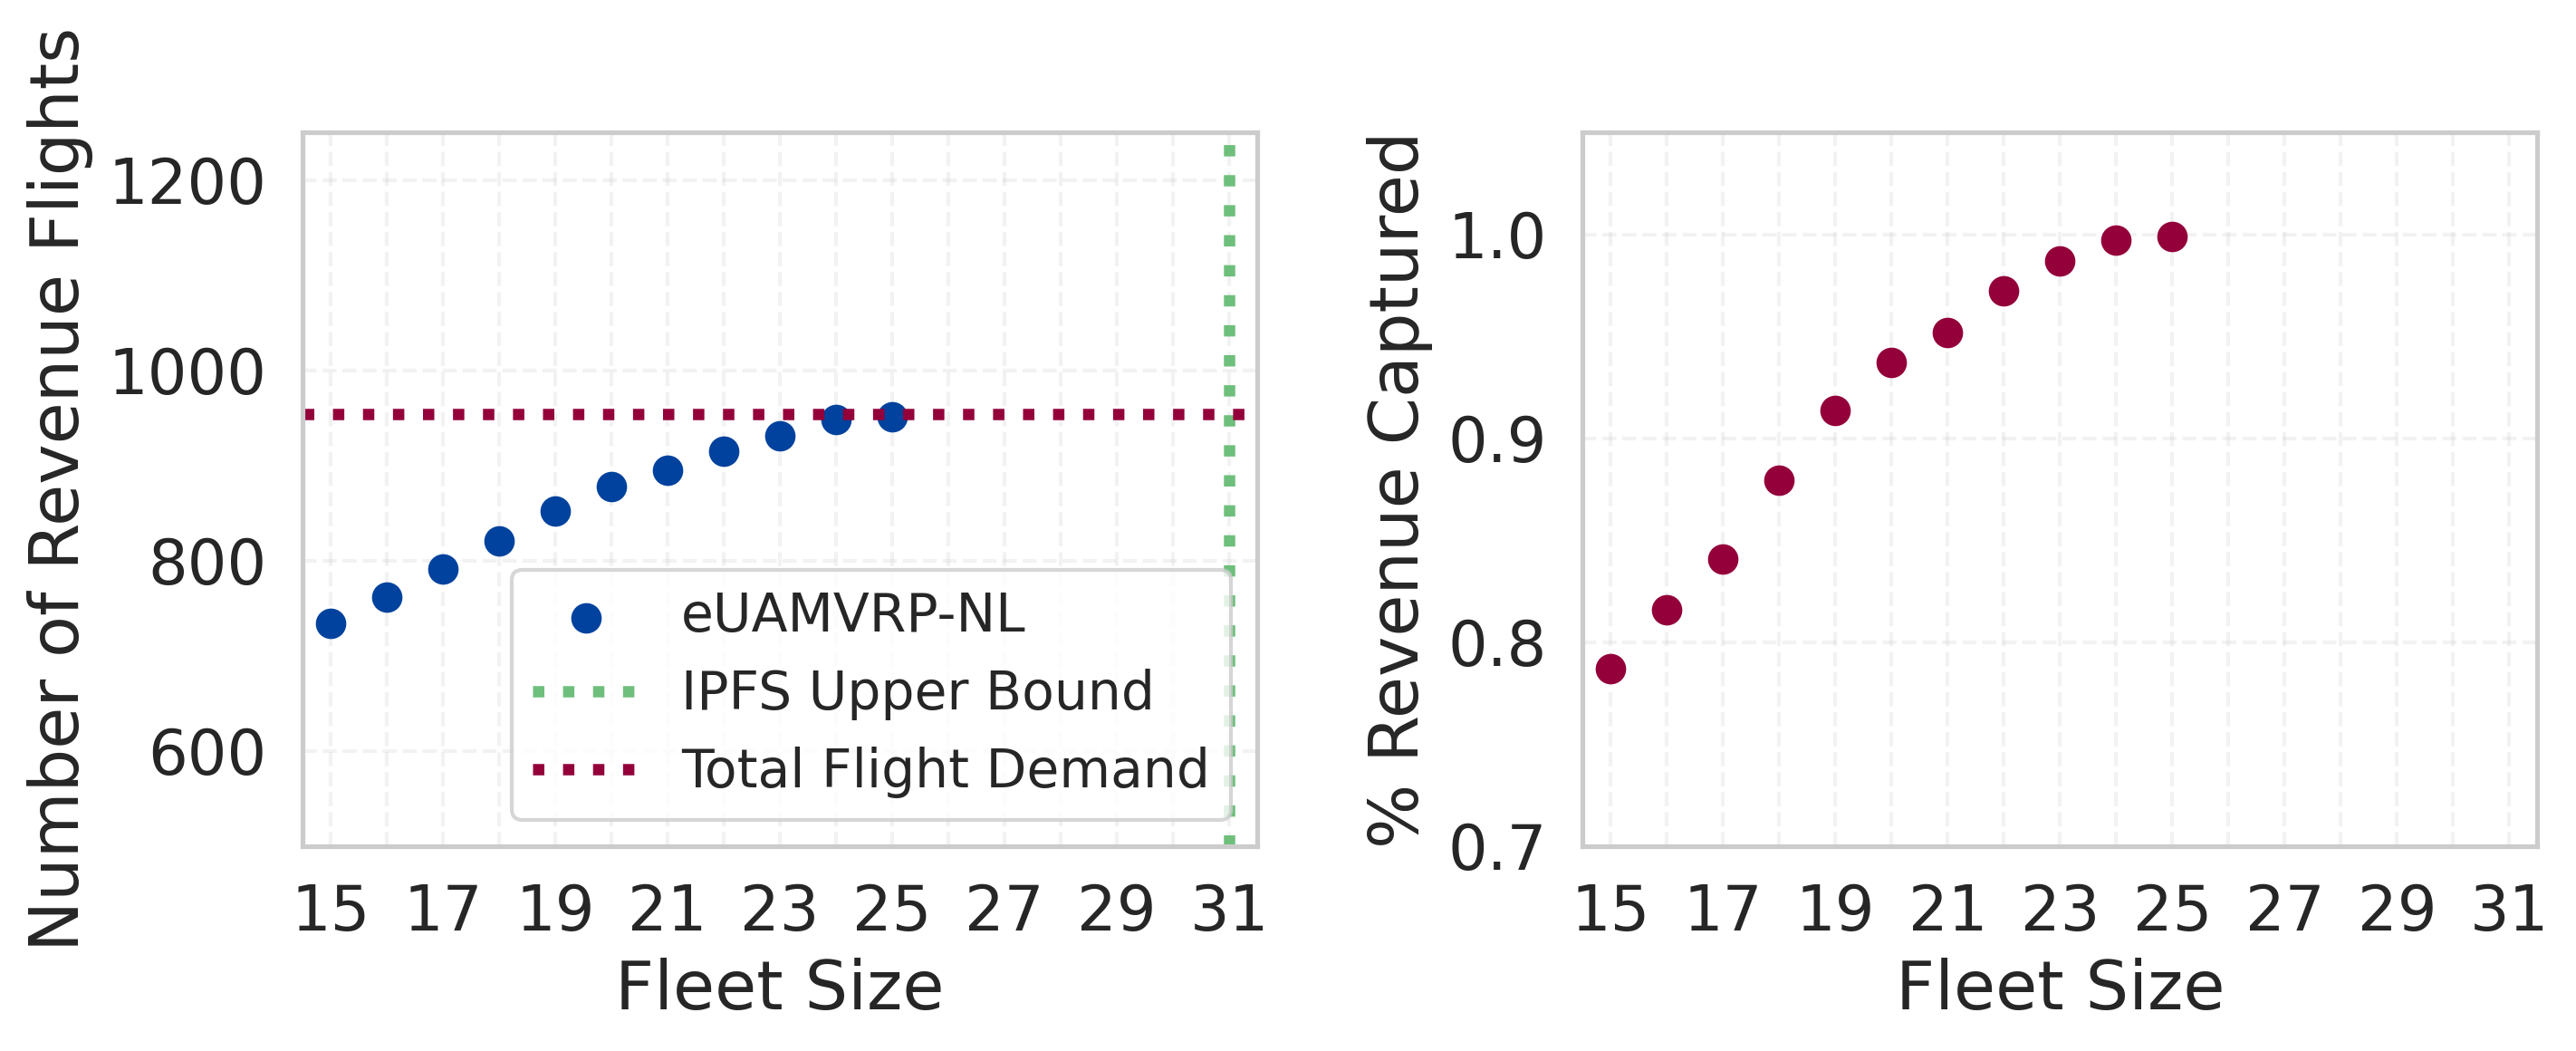

In [34]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2, dpi=300)
ax[0].scatter(df_max['fleet_size'], df_max['number_of_revenue_flights'], color=color[1], 
              s=50, label="eUAMVRP-NL")
ax[1].scatter(df_max['fleet_size'], df_max['total_revenue']/network.schedule['revenue'].sum(), color=color[0], s=50)

for i in range(2):
    ax[i].set(xlim=(14.5, 31.5), xticks=np.arange(15, 33, 2),
              xlabel="Fleet Size")
    ax[i].xaxis.set_minor_locator(MultipleLocator(1))
    ax[i].grid(True, alpha=0.25, linestyle='--', which='both')
ax[0].set(ylim=(500, 1250), ylabel="Number of Revenue Flights")
ax[1].set(ylim=(0.7, 1.05), ylabel="% Revenue Captured")
ax[0].axvline(x=31, color=color[3], linestyle=':', linewidth=3, label='IPFS Upper Bound')
ax[0].axhline(y=network.schedule.shape[0], color=color[0], linestyle=':', linewidth=3, label='Total Flight Demand')
ax[0].legend(loc='lower right')
plt.tight_layout()


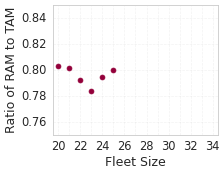

In [35]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=50)
ax.scatter(df_max['fleet_size'],  df_max['RAM']/ df_max['TAM'], color=color[0], s=50)
ax.set(xlim=(19.5, 34.5), ylim=(0.75, 0.85), xticks=np.arange(20, 36, 2),
            xlabel="Fleet Size", ylabel="Ratio of RAM to TAM")
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, alpha=0.25, linestyle='--', which='both')
plt.tight_layout()


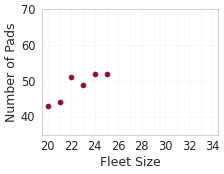

In [36]:
fig, ax = plt.subplots(figsize=(5, 4), dpi=50)
ax.scatter(df_max['fleet_size'], df_max['total_pads'], color=color[0], s=50)
ax.set(xlim=(19.5, 34.5), ylim=(35, 70), xticks=np.arange(20, 36, 2),
            xlabel="Fleet Size", ylabel="Number of Pads")
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, alpha=0.25, linestyle='--', which='both')
plt.tight_layout()

#### Infrastructure sizing

In [41]:
path = 'output/ECO_WAIT10_FARE3/'
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

required_pads = {}
for row in df['pads_at_vertiport']:
    for key, value in row.items():
        # Keep the max value seen so far for each key
        if key not in required_pads:
            required_pads[key] = value
        else:
            required_pads[key] = max(required_pads[key], value)
required_pads

{'LAX': 13,
 'DTLA': 6,
 'LGB': 4,
 'WDHL': 4,
 'UVS': 6,
 'ANH': 4,
 'HWD': 6,
 'PSD': 5,
 'BVH': 4}

In [42]:
statistics_0

{'fleet_size': 25,
 'total_pads': 52,
 'pads_at_vertiport': {'LAX': 13,
  'DTLA': 6,
  'LGB': 4,
  'WDHL': 4,
  'UVS': 6,
  'ANH': 4,
  'HWD': 6,
  'PSD': 5,
  'BVH': 4},
 'max_takeoff_per_hour': {'LAX': 45,
  'DTLA': 19,
  'LGB': 6,
  'WDHL': 6,
  'UVS': 9,
  'ANH': 9,
  'HWD': 9,
  'PSD': 11,
  'BVH': 9},
 'number_of_aircraft_hours': 217.42,
 'number_of_flights': 1178,
 'number_of_revenue_flights': 951,
 'number_of_repositioning_flights': 227,
 'percentage_repositioning_flights': 0.1927,
 'energy_consumption_kWh': 19890.5,
 'TAM': 16674.19,
 'RAM': 13335.94,
 'total_revenue': 89187.86705650609,
 'average_load_factor': 0.5818}

#### Patterns in opex and revenue

In [44]:
path = 'output/ECO_WAIT10_FARE3/'
policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()

In [45]:
rev = {i:0 for i in vertiports if i != "LAX"}
rev_hours = {i:0 for i in vertiports if i != "LAX"}
repo_hours = {i:0 for i in vertiports if i != "LAX"}
for idx, row in policy_0.iterrows():
    sequence = row['tour_sequence'].split("-")
    for i in range(len(sequence)-1):
        origin = sequence[i]
        destination = sequence[i+1]
        if origin == "LAX":
            market = destination
        elif destination == "LAX":
            market = origin
        
        rev[market] += row["tour_revenue"]/ row["tour_length"]
        rev_hours[market] += row["duration"] / row["tour_length"]

    if (row['next_origin'] != 0) & (row['next_origin'] != 999):
        repo_hours[network.vertiport_dict_inv[row['next_origin']]] += row['repo_flight_duration']


In [46]:
joined = pd.DataFrame({
    'revenue': rev,
    'revenue_hours': rev_hours,
    'repo_hours': repo_hours
}).reset_index()
joined['unit_rev_per_aircraft_hour'] = joined['revenue'] / (joined['revenue_hours'] + joined['repo_hours']) * 60

num_pax_per_market = network.schedule.groupby(["od"])['num_pax'].sum().reset_index()
num_pax_per_market['market'] = num_pax_per_market['od'].apply(lambda x: x if x.split("_")[0] == "LAX" else x.split("_")[1] + "_" + x.split("_")[0])
num_pax_per_market['market'] = num_pax_per_market['market'].apply(lambda x: x.split("_")[1])
num_pax_per_market = num_pax_per_market.groupby("market")['num_pax'].sum().reset_index()
joined = pd.merge(num_pax_per_market, joined, left_on='market', right_on='index')

num_flight_per_market = network.schedule.groupby(["od"]).count().reset_index()
num_flight_per_market['market'] = num_flight_per_market['od'].apply(lambda x: x if x.split("_")[0] == "LAX" else x.split("_")[1] + "_" + x.split("_")[0])
num_flight_per_market['market'] = num_flight_per_market['market'].apply(lambda x: x.split("_")[1])
num_flight_per_market = num_flight_per_market.groupby("market")['revenue'].sum().reset_index()
num_flight_per_market = num_flight_per_market.rename(columns={'revenue': 'num_flight'})
joined = pd.merge(num_flight_per_market, joined, left_on='market', right_on='index').drop(columns=['market_x', 'market_y'])

In [47]:
joined['load_factor'] = joined['num_pax'] / joined['num_flight'] /4
joined['repo_hour_percentage'] = joined['repo_hours'] / (joined['repo_hours'] + joined['revenue_hours'])

In [48]:
joined

,num_flight,num_pax,index,revenue,revenue_hours,repo_hours,unit_rev_per_aircraft_hour,load_factor,repo_hour_percentage
0,77,129,ANH,11011.631059,1100.0,325,463.647624,0.418831,0.228070
1,98,158,BVH,4518.180651,962.5,250,223.580073,0.403061,0.206186
2,178,541,DTLA,16997.620732,1827.5,580,423.616716,0.759831,0.240914
3,161,413,HWD,14043.992221,1637.5,165,467.483791,0.641304,0.091540
4,109,224,LGB,11091.377040,1305.0,95,475.344730,0.513761,0.067857
5,168,453,PSD,17199.629896,1700.0,180,548.924358,0.674107,0.095745
6,107,218,UVS,9410.595181,1095.0,240,422.948098,0.509346,0.179775
7,56,84,WDHL,4914.840277,772.5,145,321.406449,0.375,0.158038


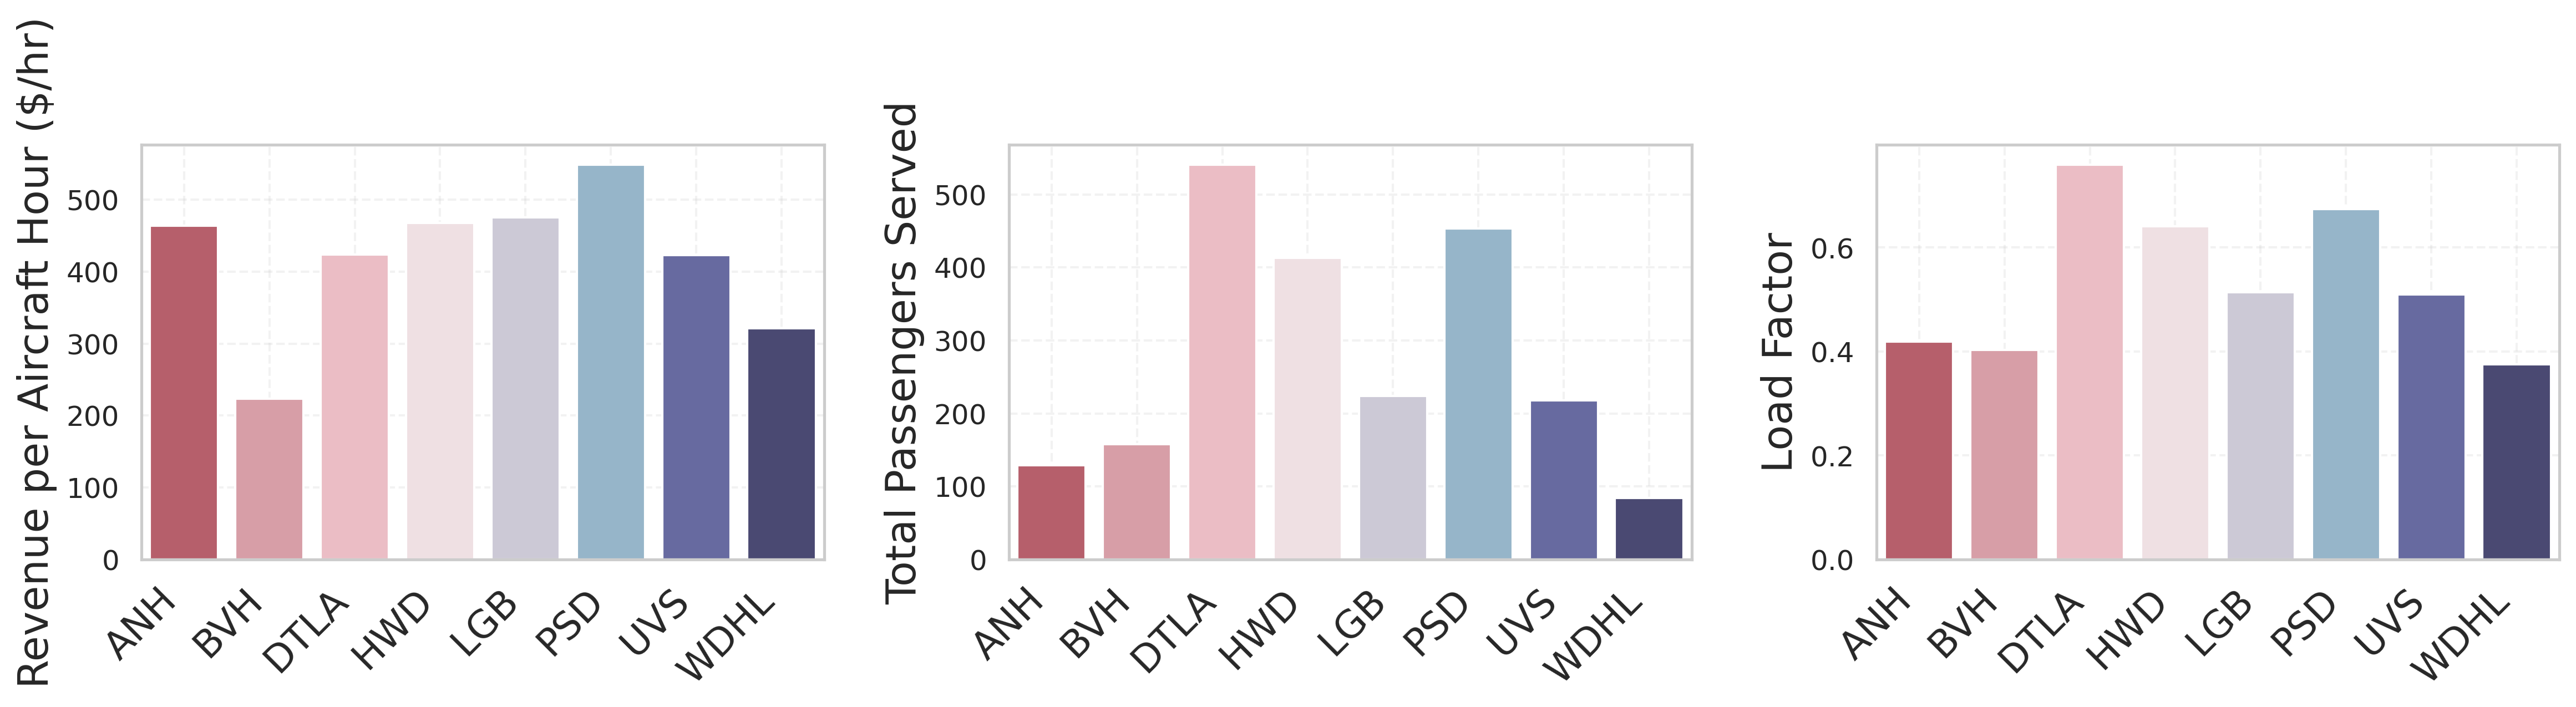

In [49]:
fig, ax = plt.subplots(figsize=(16, 4), dpi=300, ncols=3)
sns.barplot(data=joined, x='index', y='unit_rev_per_aircraft_hour', ax=ax[0], palette=custom_colors)
sns.barplot(data=joined, x='index', y='num_pax', ax=ax[1], palette=custom_colors)
sns.barplot(data=joined, x='index', y='load_factor', ax=ax[2], palette=custom_colors)
ax[0].set_ylabel("Revenue per Aircraft Hour ($/hr)")
ax[1].set_ylabel("Total Passengers Served")
ax[2].set_ylabel("Load Factor")
for i in range(3):
    ax[i].tick_params(axis='y', labelsize=12)
    ax[i].set_xlabel("")
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')
    ax[i].grid(True, alpha=0.25, linestyle='--', which='both')


plt.tight_layout()


#### cost-revenue analysis

In [50]:
import importlib
import uam_system_model.financial_analysis.cost
importlib.reload(uam_system_model.financial_analysis.cost)
from uam_system_model.financial_analysis.cost import CostAnalyzer


In [52]:
path = 'output/ECO_WAIT10_FARE3/'

policy_0 = pd.read_csv(path + "25_4_4_4.csv")
summary_0 = FleetOpVRPSummary(network, policy_0)
statistics_0 = summary_0.get_summary_statistics()
df = pd.DataFrame([statistics_0])

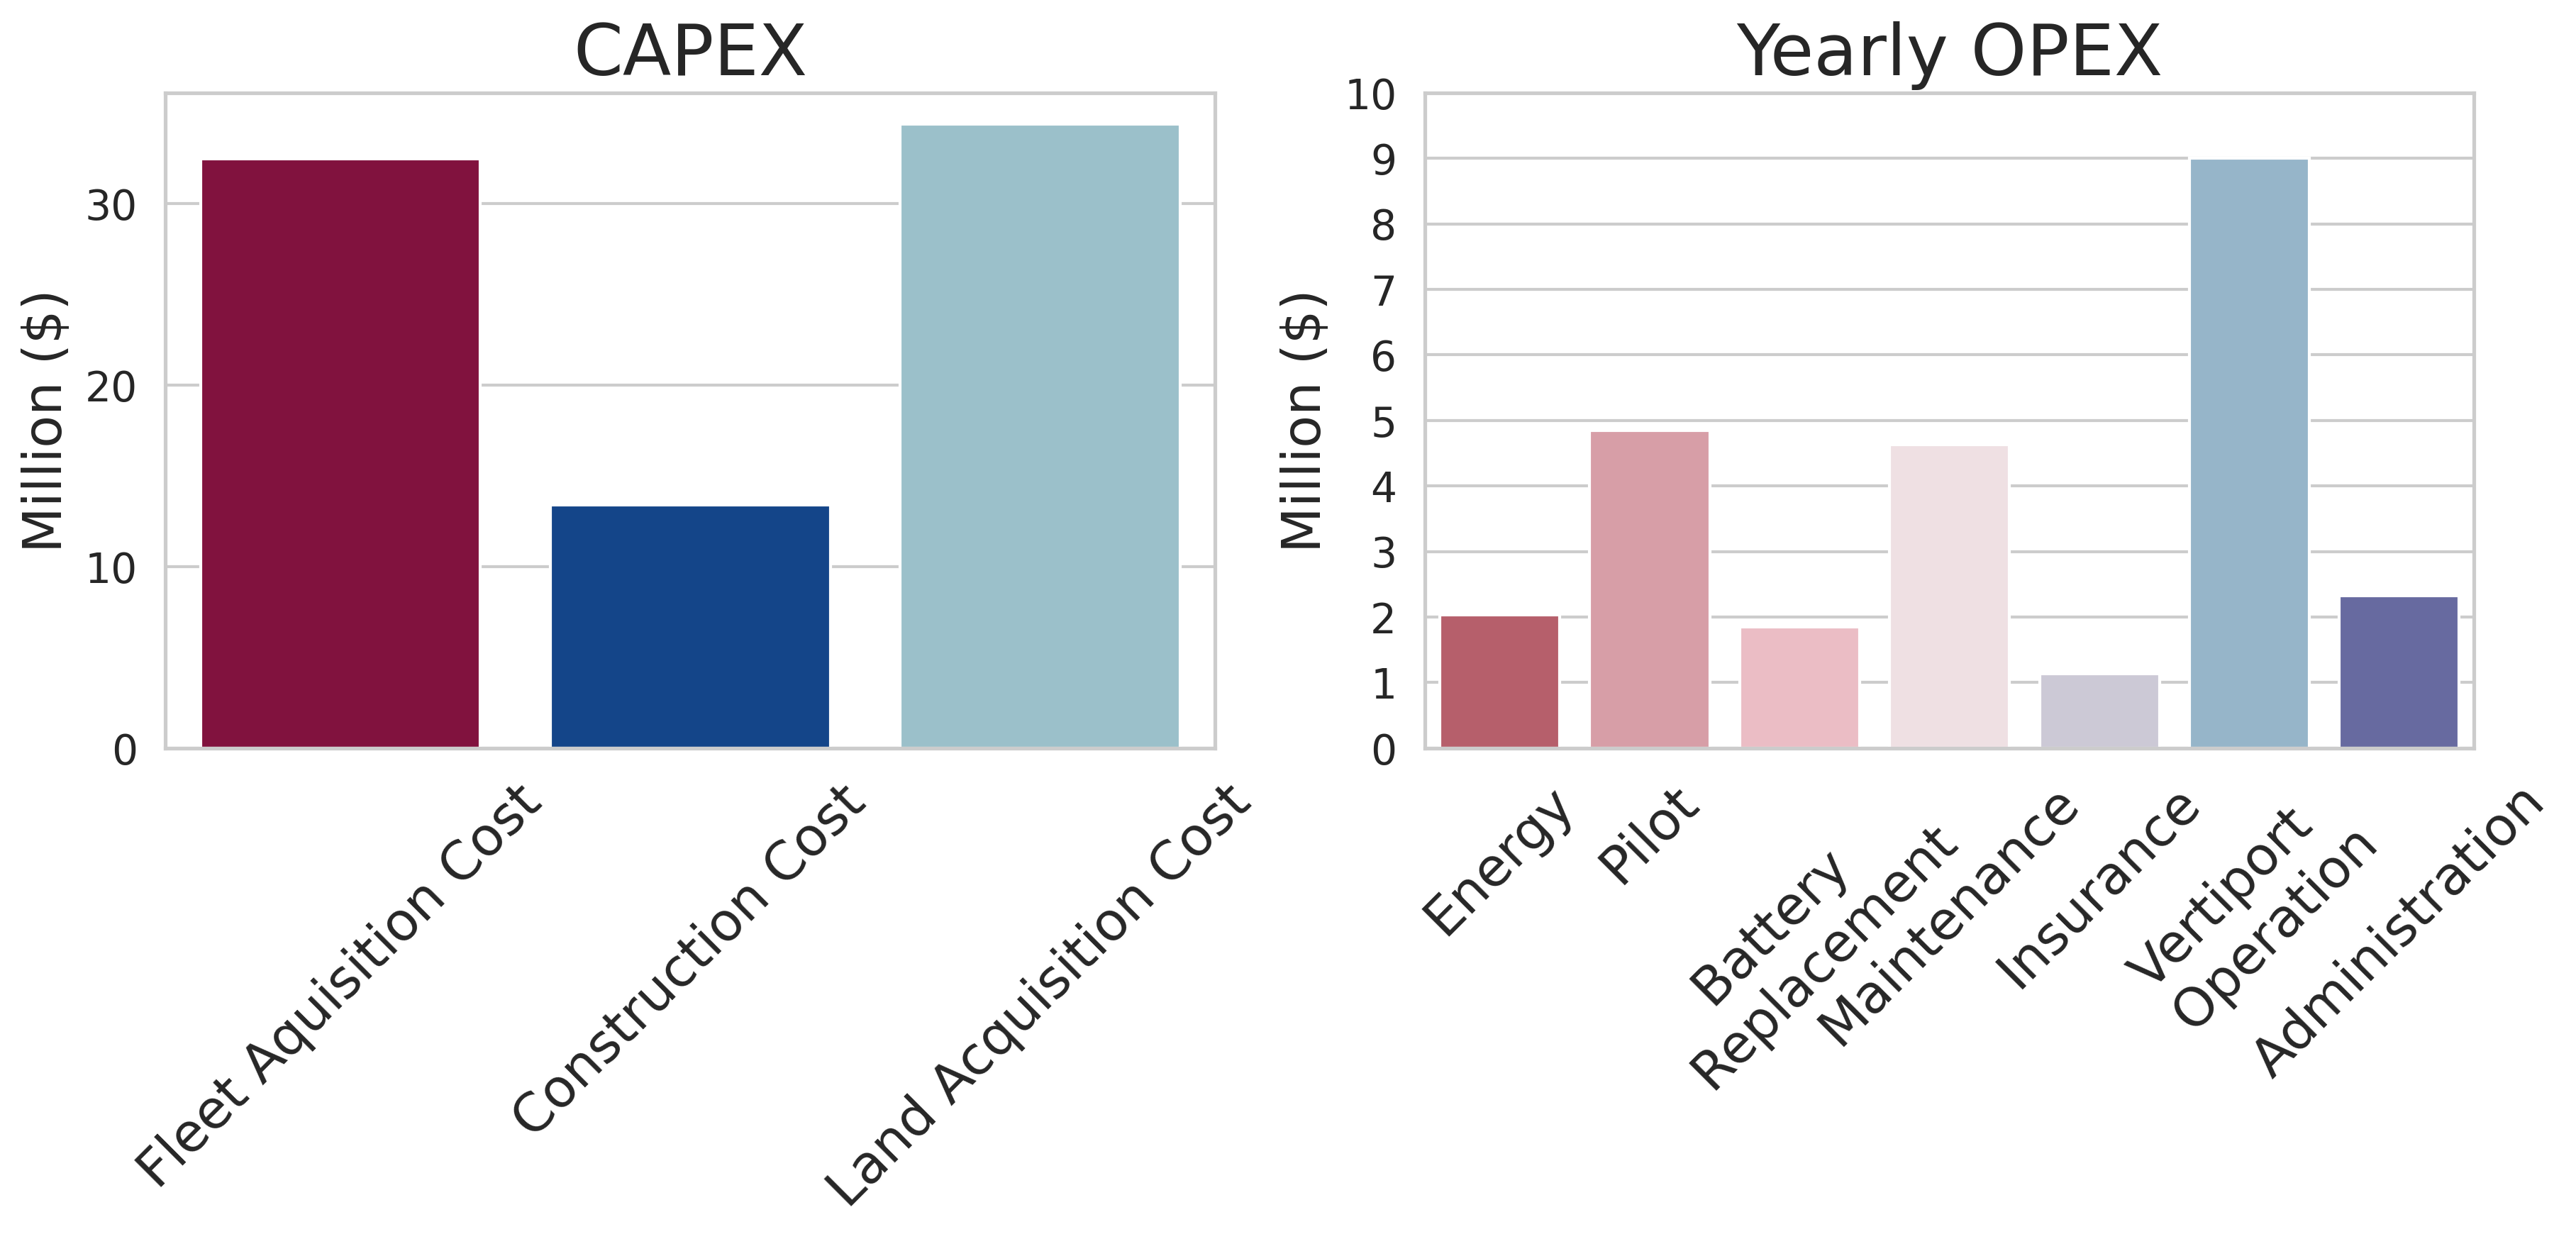

In [53]:
c = CostAnalyzer("../UAM-System-Model/uam_system_model/data/config/financial_analysis_params.json")
capex, opex, rev, prof = c.analyze(df_max[df_max['fleet_size']==25].reset_index(drop=True))
c.plot();

#### Financial projection

ROI (undiscounted) ............ : -0.28
NPV @ 8% ............. : $-22,595,775
IRR ........................... : 3.03%
Not recovered


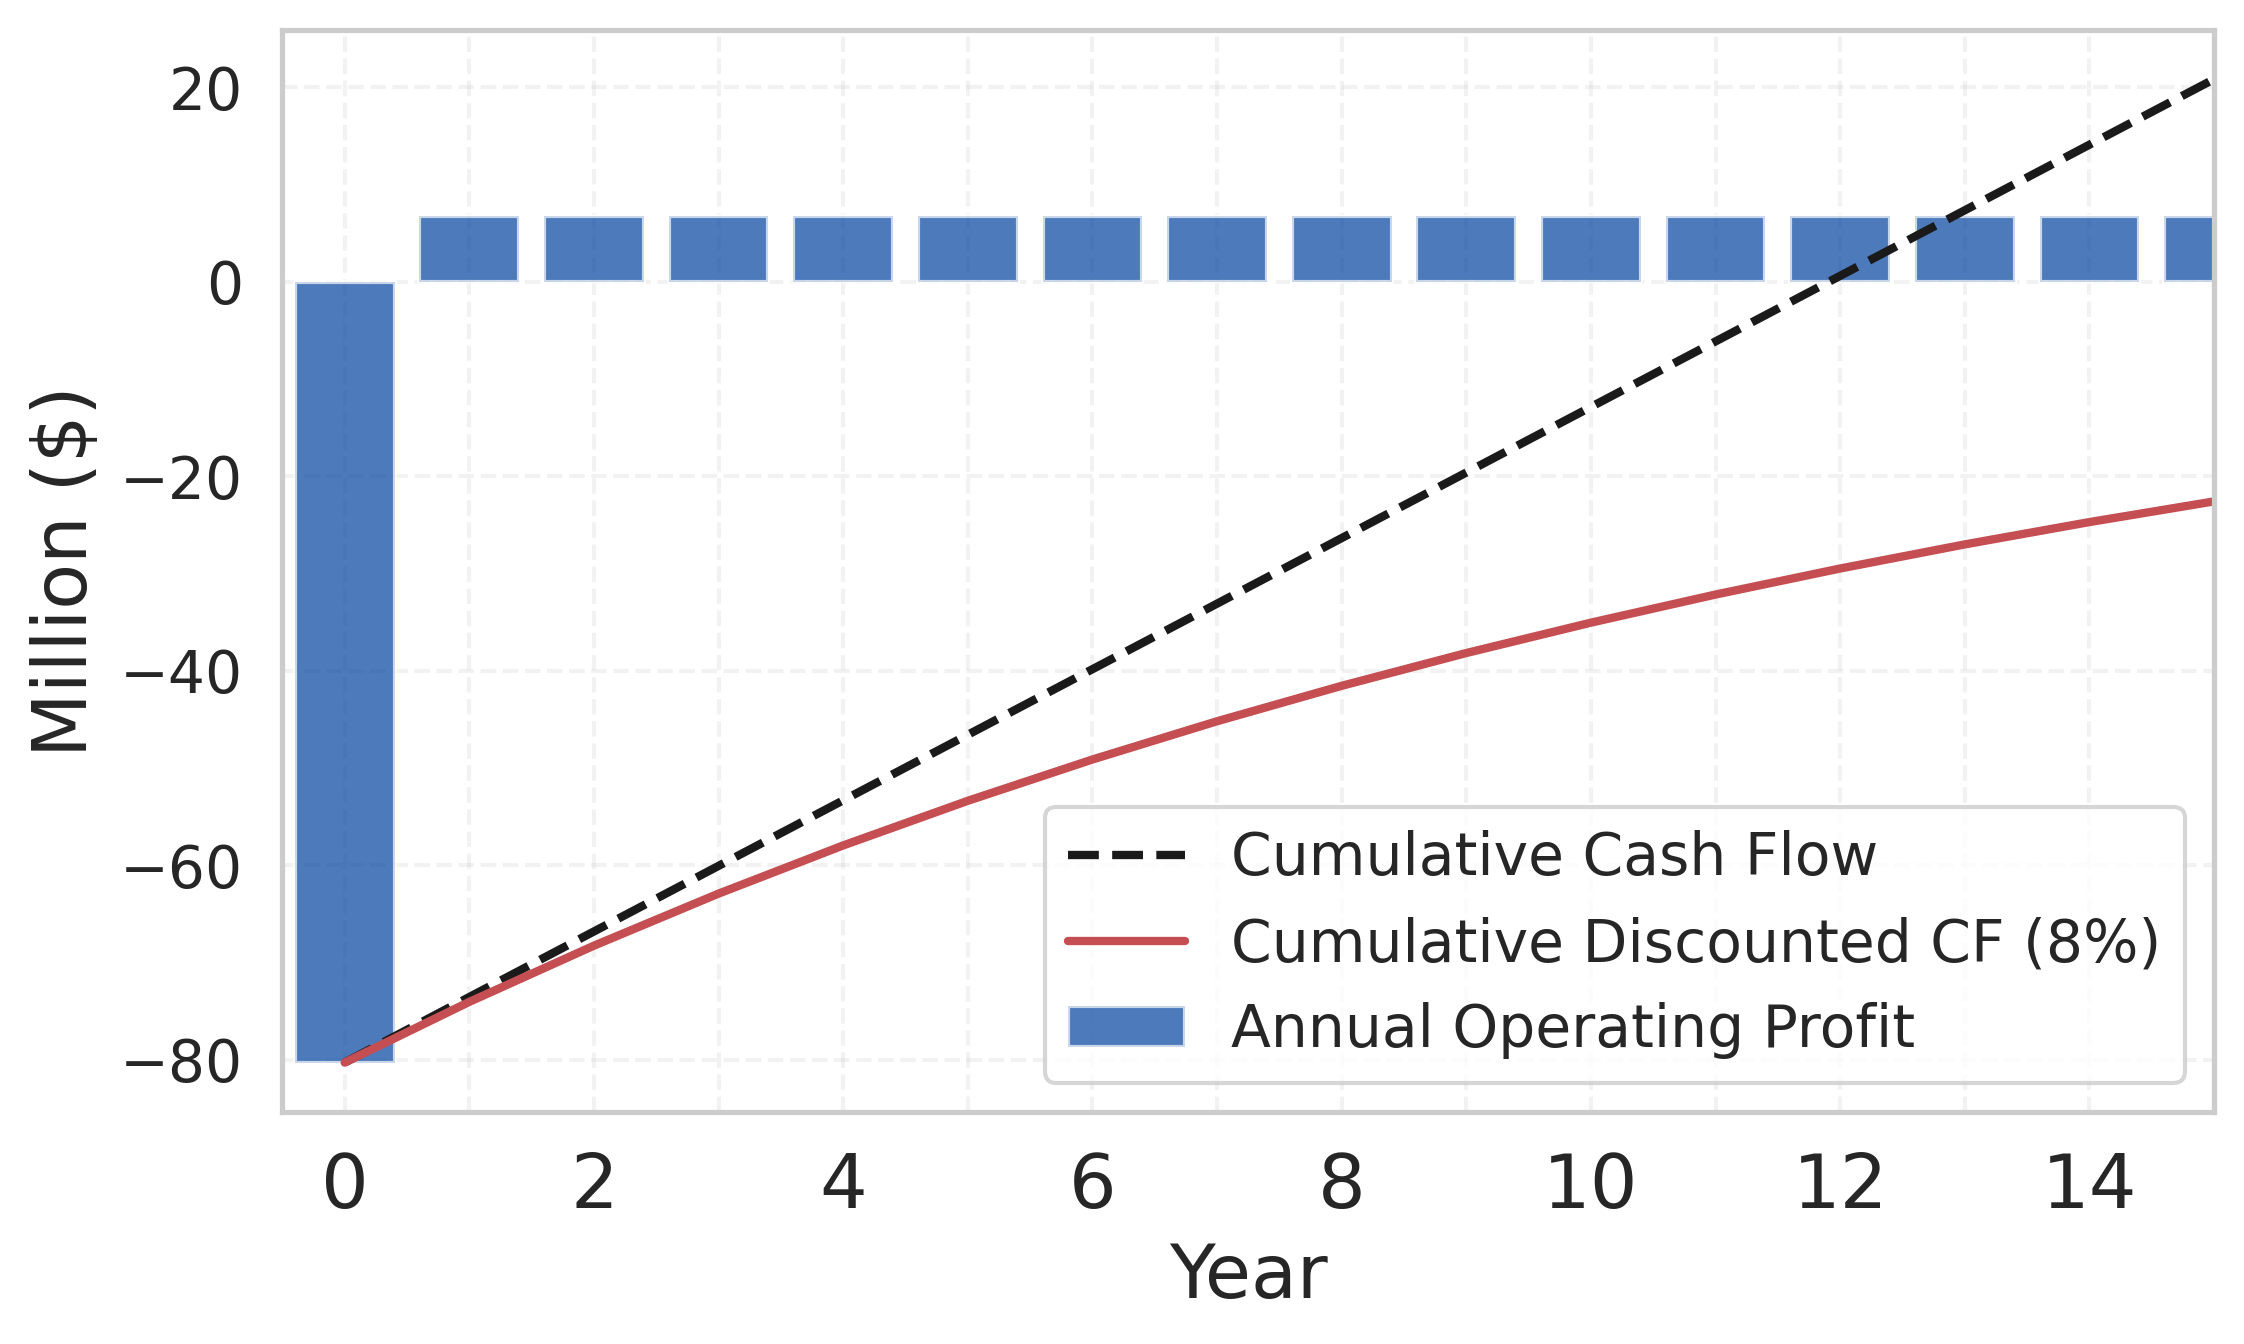

In [54]:
fig, ax, ROI, NPV, IRR, payback_year = c.projection()